# What a program-only agent can establish about an unknown environment

Companion notebook to our ARC Prize 2026 Paper Track writeup.

It runs offline and needs nothing attached but the competition itself. Every
table that comes from simulation is **computed when you run it**; the figures
measured against 500 recorded real games are shipped as two small JSON files,
because the recordings are 2.8&nbsp;GB. Each number traces to a document in the
repository (github.com/Panus15/arc-prize-2026, MIT-0) recording the run behind
it, including the numbers that contradict our earlier claims.

## Setup

The competition's `arc-agi` package supplies the frame and action types; on
Kaggle it installs from the competition's offline wheels. Our library and the
measured results follow as generated cells — scroll past them to section 1.

In [1]:
import importlib.util
import os
import pathlib
import subprocess
import sys

if importlib.util.find_spec("arcengine") is None:
    wheels = pathlib.Path("/kaggle/input/competitions/arc-prize-2026-arc-agi-3/arc_agi_3_wheels")
    source = ["--no-index", "--find-links", str(wheels)] if wheels.is_dir() else []
    subprocess.run([sys.executable, "-m", "pip", "install", "--quiet", *source, "arc-agi"],
                   check=True)
for folder in ("/tmp/arcagi_pkg/arcagi3", "/tmp/paper_data"):
    os.makedirs(folder, exist_ok=True)
print("arc-agi available:", importlib.util.find_spec("arcengine") is not None)

arc-agi available: True


In [2]:
%%writefile /tmp/arcagi_pkg/arcagi3/__init__.py
"""arcagi3, bundled into the paper notebook."""

Overwriting /tmp/arcagi_pkg/arcagi3/__init__.py


In [3]:
%%writefile /tmp/arcagi_pkg/arcagi3/actions.py
"""Action vocabulary, and the safe way to turn a frame's integers into actions.

`FrameData.available_actions` arrives as a list of plain integers, but
`GameAction` cannot be constructed from one: its value-to-member map is keyed by
`(value, action_class)` tuples, so `GameAction(1)` raises. Everything that reads
`available_actions` has to go through `action_from_value` instead.
"""

from __future__ import annotations

from arcengine import GameAction

# Movement actions as (dy, dx). ACTION5 is "interact" in the mock game.
MOVES: dict[GameAction, tuple[int, int]] = {
    GameAction.ACTION1: (-1, 0),
    GameAction.ACTION2: (1, 0),
    GameAction.ACTION3: (0, -1),
    GameAction.ACTION4: (0, 1),
}
INTERACT = GameAction.ACTION5

# ACTION6 is the one ComplexAction in the enum; the others are SimpleAction.
# Complex actions carry payload in ActionInput.data (coordinates), so a policy
# cannot emit one by picking the bare enum member.
COMPLEX_ACTIONS: frozenset[GameAction] = frozenset({GameAction.ACTION6})

# What each action means in the games, confirmed against the Milestone #1
# winner's action_names.py. ACTION7 appears in the enum but is not mapped there,
# so its meaning is still unknown.
ACTION_MEANING: dict[GameAction, str] = {
    GameAction.RESET: "RESET",
    GameAction.ACTION1: "UP",
    GameAction.ACTION2: "DOWN",
    GameAction.ACTION3: "LEFT",
    GameAction.ACTION4: "RIGHT",
    GameAction.ACTION5: "SPACE",
    GameAction.ACTION6: "MOUSE",
}


def describe(action: GameAction) -> str:
    """Human-readable name for logs and traces."""
    return ACTION_MEANING.get(action, action.name)


_BY_VALUE: dict[int, GameAction] = {action.value: action for action in GameAction}


def action_from_value(value: int) -> GameAction:
    """Map an integer out of `available_actions` back to its GameAction."""
    try:
        return _BY_VALUE[value]
    except KeyError:
        raise ValueError(f"{value} is not a GameAction value") from None


def actions_from_values(values: list[int]) -> list[GameAction]:
    """Map a whole `available_actions` list, preserving order."""
    return [action_from_value(v) for v in values]

Overwriting /tmp/arcagi_pkg/arcagi3/actions.py


In [4]:
%%writefile /tmp/arcagi_pkg/arcagi3/agent.py
"""Agent base and reference policies.

ARC-AGI-3 scores efficiency, not just completion: actions are counted against a
per-level baseline while the reasoning behind them costs nothing. So the base
class here makes two things structural rather than optional — a policy may only
return an action the current frame says is available, and every action it takes
is counted.
"""

from __future__ import annotations

import random
from abc import ABC, abstractmethod

from arcengine import FrameData, GameAction, GameState

from arcagi3.actions import INTERACT, MOVES, actions_from_values
from arcagi3.mock import CURSOR, TARGET


class IllegalActionError(RuntimeError):
    """A policy returned an action the frame did not offer."""


class BaseAgent(ABC):
    """Chooses actions from frames. Subclasses implement `choose_action`."""

    name: str = "base"

    @abstractmethod
    def choose_action(self, frames: list[FrameData], latest: FrameData) -> GameAction:
        """Pick the next action. Must be one of `latest.available_actions`."""

    def is_done(self, frames: list[FrameData], latest: FrameData) -> bool:
        return latest.state in (GameState.WIN, GameState.GAME_OVER)

    def act(self, frames: list[FrameData], latest: FrameData) -> GameAction:
        """`choose_action` with the legality check applied.

        Checking here rather than trusting the policy means a bug surfaces as a
        loud failure during development instead of as silently wasted actions in
        a scored run, where every wasted action costs efficiency.
        """
        action = self.choose_action(frames, latest)
        if action.value not in latest.available_actions:
            raise IllegalActionError(
                f"{self.name} chose {action.name}, but this frame offers "
                f"{[a.name for a in actions_from_values(latest.available_actions)]}"
            )
        return action


class RandomAgent(BaseAgent):
    """Uniform choice over the legal actions — the floor to beat.

    RESET is excluded unless it is the only option: it is always legal and never
    progresses, so including it makes the floor artificially bad.
    """

    name = "random"

    def __init__(self, seed: int | None = 0) -> None:
        self._rng = random.Random(seed)

    def choose_action(self, frames: list[FrameData], latest: FrameData) -> GameAction:
        actions = actions_from_values(latest.available_actions)
        useful = [a for a in actions if a is not GameAction.RESET]
        return self._rng.choice(useful or actions)


class GreedyAgent(BaseAgent):
    """Walks the cursor toward the target, reading both from the frame.

    This is not a general solver — it reads the mock's colour convention. It
    exists to prove the environment is solvable at the optimal action count, so
    that the efficiency numbers a real policy produces have a known ceiling.
    """

    name = "greedy"

    def choose_action(self, frames: list[FrameData], latest: FrameData) -> GameAction:
        grid = latest.frame[0]
        cursor = _find(grid, CURSOR)
        target = _find(grid, TARGET)
        available = set(actions_from_values(latest.available_actions))

        if cursor is None or target is None or cursor == target:
            if INTERACT in available:
                return INTERACT
            return _fallback(available)

        dy = target[0] - cursor[0]
        dx = target[1] - cursor[1]
        # Close the larger gap first; it keeps the walk inside the L-shaped path
        # the baseline assumes.
        preferred = []
        if abs(dy) >= abs(dx):
            preferred = [_step(dy, 0), _step(0, dx)]
        else:
            preferred = [_step(0, dx), _step(dy, 0)]

        for action in preferred:
            if action is not None and action in available:
                return action
        return _fallback(available)


def _fallback(available: set[GameAction]) -> GameAction:
    """Lowest-numbered action that is not RESET, or RESET if there is none.

    Iterating the set directly would be non-deterministic: GameAction members
    hash by identity, so set order changes between processes and the same board
    would produce different play on different runs. Anything a competition run
    reports has to be reproducible, so the tie is broken by action value.
    """
    usable = sorted(available - {GameAction.RESET}, key=lambda a: a.value)
    return usable[0] if usable else GameAction.RESET


def _find(grid: list[list[int]], symbol: int) -> tuple[int, int] | None:
    for y, row in enumerate(grid):
        for x, value in enumerate(row):
            if value == symbol:
                return y, x
    return None


def _step(dy: int, dx: int) -> GameAction | None:
    if dy == 0 and dx == 0:
        return None
    unit = (0 if dy == 0 else (1 if dy > 0 else -1), 0 if dx == 0 else (1 if dx > 0 else -1))
    for action, delta in MOVES.items():
        if delta == unit:
            return action
    return None

Overwriting /tmp/arcagi_pkg/arcagi3/agent.py


In [5]:
%%writefile /tmp/arcagi_pkg/arcagi3/budget.py
"""Running an agent against an environment, and counting what it spent.

The competition's scorecard reports `level_actions` against
`level_baseline_actions`, so completion alone says little. These helpers report
both, and the ratio between them, which is the number a policy has to move.
"""

from __future__ import annotations

from collections.abc import Callable
from dataclasses import dataclass

from arcengine import FrameData, GameState

from arcagi3.agent import BaseAgent
from arcagi3.mock import MockEnvironment


@dataclass(frozen=True)
class RunResult:
    """What one episode cost."""

    agent: str
    state: GameState
    levels_completed: int
    total_levels: int
    actions_used: int
    baseline_actions: int
    truncated: bool

    @property
    def won(self) -> bool:
        return self.state is GameState.WIN

    @property
    def efficiency(self) -> float | None:
        """Baseline actions per action spent. 1.0 is a perfect run, less is worse.

        None when nothing was spent, which would otherwise divide by zero.
        """
        if self.actions_used == 0:
            return None
        return self.baseline_actions / self.actions_used

    def summary(self) -> str:
        eff = "n/a" if self.efficiency is None else f"{self.efficiency:.2%}"
        outcome = "WIN" if self.won else ("truncated" if self.truncated else self.state.name)
        return (
            f"{self.agent:<10} {outcome:<10} "
            f"levels {self.levels_completed}/{self.total_levels}  "
            f"actions {self.actions_used} (baseline {self.baseline_actions}, efficiency {eff})"
        )


def run_episode(
    agent: BaseAgent,
    env: MockEnvironment | None = None,
    *,
    max_actions: int = 500,
    should_stop: Callable[[int, int], bool] | None = None,
) -> RunResult:
    """Play one episode, stopping at a win, a loss, or `max_actions`.

    The cap exists because a policy that never reaches the target would
    otherwise loop forever; hitting it is reported as `truncated` rather than
    being quietly folded into a loss.

    `should_stop(actions_used, levels_completed)` lets a caller give up early on
    a game that is going nowhere. Competition mode scores every environment
    whether or not it was played and allows one interaction each, so actions
    poured into a hopeless game are actions another game never gets.
    """
    env = env or MockEnvironment()
    latest: FrameData = env.reset()
    frames: list[FrameData] = [latest]
    truncated = False

    while not agent.is_done(frames, latest):
        if env.actions_used >= max_actions:
            truncated = True
            break
        if should_stop is not None and should_stop(env.actions_used, latest.levels_completed):
            truncated = True
            break
        latest = env.step(agent.act(frames, latest))
        frames.append(latest)

    return RunResult(
        agent=agent.name,
        state=latest.state,
        levels_completed=latest.levels_completed,
        total_levels=latest.win_levels,
        actions_used=env.actions_used,
        baseline_actions=env.optimal_actions,
        truncated=truncated,
    )

Overwriting /tmp/arcagi_pkg/arcagi3/budget.py


In [6]:
%%writefile /tmp/arcagi_pkg/arcagi3/click_mock.py
"""An offline stand-in for the click-driven games.

Eight of the 25 official games are never played with a direction — across three
passes each they are almost entirely MOUSE, and one of them, ft09, is the
highest-scoring game in the winner's whole run. A policy that only knows how to
walk cannot touch roughly a third of the field, including its most winnable
game, so those games need an environment to develop against too.

The game here is deliberately plain: several objects on a board, one colour of
which responds to a click. It is not meant to be interesting, it is meant to
have a known optimal action count — one click per level — so that efficiency
is measured rather than guessed at.
"""

from __future__ import annotations

from dataclasses import dataclass

from arcengine import FrameData, GameAction, GameState
from arcengine.enums import ActionInput

Grid = list[list[int]]
Cell = tuple[int, int]

EMPTY = 0
BLOCK = 2  # every object is a BLOCK x BLOCK square


@dataclass(frozen=True)
class ClickLevel:
    """One board: some objects, one of which is the one worth clicking."""

    height: int
    width: int
    objects: tuple[tuple[int, Cell], ...]
    target_colour: int

    def colour_at(self, cell: Cell) -> int | None:
        """The colour of the object covering `cell`, if any."""
        for colour, (top, left) in self.objects:
            if top <= cell[0] < top + BLOCK and left <= cell[1] < left + BLOCK:
                return colour
        return None


LEVELS: tuple[ClickLevel, ...] = (
    ClickLevel(10, 10, ((3, (1, 1)), (7, (1, 6)), (5, (6, 1))), target_colour=7),
    ClickLevel(10, 10, ((7, (6, 6)), (4, (1, 1)), (5, (1, 6))), target_colour=7),
    ClickLevel(12, 12, ((5, (1, 1)), (3, (9, 9)), (7, (5, 5)), (4, (9, 1))), target_colour=7),
)


class ClickEnvironment:
    """A board played entirely by clicking, exposing the same surface as the walker."""

    game_id = "mock-click"

    def __init__(self, levels: tuple[ClickLevel, ...] = LEVELS) -> None:
        if not levels:
            raise ValueError("need at least one level")
        self._levels = levels
        self._index = 0
        self._state = GameState.NOT_PLAYED
        self._actions_used = 0
        self._levels_completed = 0

    @property
    def actions_used(self) -> int:
        return self._actions_used

    @property
    def optimal_actions(self) -> int:
        """One correct click per level is the best any player can do."""
        return len(self._levels)

    @property
    def level(self) -> ClickLevel:
        return self._levels[self._index]

    def reset(self) -> FrameData:
        self._index = 0
        self._state = GameState.NOT_FINISHED
        self._levels_completed = 0
        return self._frame(GameAction.RESET, full_reset=True)

    def step(self, action: GameAction) -> FrameData:
        """Apply a click. A click on the wrong object costs a turn and does nothing."""
        if self._state in (GameState.WIN, GameState.GAME_OVER):
            return self._frame(action)

        self._actions_used += 1
        if action is GameAction.RESET:
            return self._frame(action, full_reset=True)

        if action is GameAction.ACTION6:
            target = self._clicked_cell(action)
            if target is not None and self.level.colour_at(target) == self.level.target_colour:
                self._advance()
        return self._frame(action)

    def available_actions(self) -> list[GameAction]:
        if self._state in (GameState.WIN, GameState.GAME_OVER):
            return []
        return [GameAction.RESET, GameAction.ACTION6]

    # --- internals ----------------------------------------------------------

    @staticmethod
    def _clicked_cell(action: GameAction) -> Cell | None:
        """Where the click landed, read the way the SDK carries it.

        The payload rides on the shared enum member — that is the SDK's own
        contract — and is x/y, where y is the row and x the column.
        """
        data = getattr(action, "action_data", None)
        if data is None:
            return None
        row, col = getattr(data, "y", None), getattr(data, "x", None)
        if row is None or col is None:
            return None
        return int(row), int(col)

    def _advance(self) -> None:
        self._levels_completed += 1
        if self._index + 1 < len(self._levels):
            self._index += 1
        else:
            self._state = GameState.WIN

    def _grid(self) -> Grid:
        level = self.level
        grid = [[EMPTY] * level.width for _ in range(level.height)]
        for colour, (top, left) in level.objects:
            for r in range(top, min(top + BLOCK, level.height)):
                for c in range(left, min(left + BLOCK, level.width)):
                    grid[r][c] = colour
        return grid

    def _frame(self, action: GameAction, *, full_reset: bool = False) -> FrameData:
        return FrameData(
            game_id=self.game_id,
            frame=[self._grid()],
            state=self._state,
            levels_completed=self._levels_completed,
            win_levels=len(self._levels),
            action_input=ActionInput(id=action, data={}),
            guid=None,
            full_reset=full_reset,
            available_actions=[a.value for a in self.available_actions()],
        )

Overwriting /tmp/arcagi_pkg/arcagi3/click_mock.py


In [7]:
%%writefile /tmp/arcagi_pkg/arcagi3/clicker.py
"""A policy for the games that are played by clicking rather than walking.

Roughly a third of the official games never take a directional input at all —
they are driven almost entirely by MOUSE — so the walking policy has nothing to
offer there. The approach is the same one that works for the controls: try
things, watch what the board does, and keep what paid off.

Here the thing being learned is which objects respond to a click. Objects are
identified by colour, because that is what generalises across levels: the
layout changes every level, the palette usually does not.
"""

from __future__ import annotations

from collections import Counter

from arcengine import FrameData, GameAction

from arcagi3.actions import actions_from_values
from arcagi3.agent import BaseAgent
from arcagi3.perception import Node, segment
from arcagi3.sdk_adapter import mouse_action

Cell = tuple[int, int]

# How much a completed level outweighs a click that did nothing. Levels are the
# only discriminating signal and arrive at about 1% of clicks, so one has to be
# worth more than a handful of dead ends.
LEVEL_REWARD = 3

# Clicks without a level between presses of ACTION5, when the game offers it.
# In the recordings of sb26, the one public game offering only ACTION5 and
# clicks, all 22 level completions came on ACTION5, never on a click: clicking
# sets something up and ACTION5 submits it. One game is thin evidence for a
# rule, so the rule is cheap: one action in every seven.
CONFIRM_EVERY = 6


class ClickAgent(BaseAgent):
    """Clicks objects, learns which colours answer, then clicks those."""

    name = "clicker"

    def __init__(self) -> None:
        self._responsive: Counter[int] = Counter()
        self._inert: Counter[int] = Counter()
        self._clicked: set[tuple[int, Cell]] = set()
        self._before: list[list[int]] | None = None
        self._target: Cell | None = None
        self._target_colour: int | None = None
        self._levels_seen = 0
        self._clicks_since_confirm = 0

    def choose_action(self, frames: list[FrameData], latest: FrameData) -> GameAction:
        board = latest.frame[0]
        self._learn(board, latest.levels_completed)

        available = actions_from_values(latest.available_actions)
        if GameAction.ACTION5 in available and self._clicks_since_confirm >= CONFIRM_EVERY:
            self._clicks_since_confirm = 0
            self._before, self._target, self._target_colour = None, None, None
            return GameAction.ACTION5
        if GameAction.ACTION6 not in available:
            # Nothing to click with; RESET is the only thing that can change that.
            return GameAction.RESET

        choice = self._pick_target(board)
        if choice is None:
            return GameAction.RESET

        cell, colour = choice
        self._clicks_since_confirm += 1
        self._before = [row[:] for row in board]
        self._target, self._target_colour = cell, colour
        return mouse_action(*cell)

    def mouse_target(self) -> Cell | None:
        """Where the click just chosen points — read by the SDK adapter."""
        return self._target

    # --- learning ----------------------------------------------------------

    def _learn(self, board: list[list[int]], levels_completed: int) -> None:
        """Credit or blame the colour just clicked for what the board did."""
        if self._before is None or self._target_colour is None:
            # Not after a click of ours (the first frame, or after ACTION5). A
            # level that arrived anyway belongs to no colour, but it must still
            # be counted, or the next click would be credited with it.
            if levels_completed > self._levels_seen:
                self._levels_seen = levels_completed
                self._clicks_since_confirm = 0
            return
        colour = self._target_colour
        # Capture the previous board before clearing it: comparing against the
        # cleared field would make every click look like it changed something.
        previous = self._before
        self._before, self._target_colour = None, None

        # A completed level is the only positive evidence worth having, and it
        # arrives on a board that has already been replaced — so check it first.
        if levels_completed > self._levels_seen:
            self._levels_seen = levels_completed
            self._responsive[colour] += LEVEL_REWARD
            self._clicks_since_confirm = 0
            return
        if board == previous:
            # Nothing at all happened. Rare in the real games, but where it does
            # happen it is the cheapest negative evidence available.
            self._inert[colour] += 1
        # A board that merely changed says nothing: nearly every click does that.

    def _score(self, colour: int) -> int:
        return self._responsive[colour] - self._inert[colour]

    # --- acting ------------------------------------------------------------

    def _pick_target(self, board: list[list[int]]) -> tuple[Cell, int] | None:
        """Where to click next, and the colour of what is being clicked."""
        nodes = segment(board).nodes
        if not nodes:
            return None

        known = [n for n in nodes if self._score(n.colour) > 0]
        if known:
            # A colour that has paid out before is worth clicking again, even
            # somewhere it has not been tried: the layout moves, the rule does not.
            best = max(known, key=lambda n: (self._score(n.colour), -n.top_left[0]))
            return _centre(best), best.colour

        fresh = [n for n in nodes if (n.colour, _centre(n)) not in self._clicked]
        untested = [n for n in fresh if self._score(n.colour) == 0]
        pool = untested or fresh or list(nodes)
        # Ties break by position so that play is reproducible.
        choice = min(pool, key=lambda n: (-self._score(n.colour), n.top_left))
        self._clicked.add((choice.colour, _centre(choice)))
        return _centre(choice), choice.colour


def _centre(node: Node) -> Cell:
    """A cell inside the object, biased to its middle so the click lands on it."""
    top, left, bottom, right = node.bbox
    return (top + bottom) // 2, (left + right) // 2

Overwriting /tmp/arcagi_pkg/arcagi3/clicker.py


In [8]:
%%writefile /tmp/arcagi_pkg/arcagi3/control.py
"""Working out which object the buttons move, on boards that will not hold still.

`effects.diff` can say "one object moved two left", which is enough to learn the
controls on a tidy board. Real ARC-AGI-3 boards are not tidy: measured over 2,276
recorded movement transitions from 25 official games, exactly 10 of them — 0.4% —
produced a single unambiguous object movement. Sprites change shape between
frames, HUD bars tick, and things appear and vanish, so matching objects by an
exact shape hash loses the player almost every time.

What survives that noise is coarser: the centre of mass of each colour. A sprite
that animates while moving still shifts its colour's centroid in the direction it
went, and a HUD bar that ticks every step shifts the same way no matter which
button was pressed — so requiring the shift to *depend on the action* separates
the two. On the same recordings this recovers 79% of action-to-direction
mappings, and gets every mapping right in 11 of 17 games where the method fires.
"""

from __future__ import annotations

from collections import Counter, defaultdict
from collections.abc import Collection
from dataclasses import dataclass, field

from arcengine import GameAction

from arcagi3.actions import describe

Grid = list[list[int]]
Delta = tuple[int, int]

# A colour covering more than this share of the board is scenery, not a sprite.
# Measured: the player's colour never came close to this on the recorded games.
MAX_SPRITE_SHARE = 0.10

# Centroid shifts smaller than this are noise from a sprite changing shape in
# place rather than evidence of movement.
MOVEMENT_EPSILON = 0.05

# Below this many observations an action's dominant direction is not yet worth
# believing; three was enough to separate signal from noise on the recordings.
MIN_OBSERVATIONS = 3


# How far a sprite is assumed to travel in one action. Two covers a normal step
# and a little overshoot without making the search expensive.
MAX_STEP = 2


def colour_cells(grid: Grid) -> dict[int, set[tuple[int, int]]]:
    """Every cell of every colour, in one pass."""
    cells: dict[int, set[tuple[int, int]]] = defaultdict(set)
    for r, row in enumerate(grid):
        for c, value in enumerate(row):
            cells[value].add((r, c))
    return cells


def overlap_displacement(
    before: set[tuple[int, int]],
    after: set[tuple[int, int]],
    max_step: int = MAX_STEP,
) -> Delta | None:
    """The shift that best lines a colour's cells up between two frames.

    A centroid is the obvious way to measure this and it is fragile: a sprite
    that animates asymmetrically gains a cell on one side, which drags the mean
    sideways and turns a straight move into a diagonal one. Aligning the cells
    themselves does not care about the extra cell, only about where the body of
    the shape went.

    Ties prefer a real move over standing still, because an action was taken and
    "nothing moved" should have to be the only explanation rather than merely a
    tied one — that single rule is what makes this exact rather than
    approximate on an animating sprite.
    """
    if not before or not after:
        return None

    scored: list[tuple[int, Delta]] = []
    for dr in range(-max_step, max_step + 1):
        for dc in range(-max_step, max_step + 1):
            shifted = {(r + dr, c + dc) for r, c in before}
            scored.append((len(shifted & after), (dr, dc)))

    best = max(count for count, _ in scored)
    if best == 0:
        return None  # nothing lines up; the shape did not merely move
    tied = [delta for count, delta in scored if count == best]
    moves = [delta for delta in tied if delta != (0, 0)]
    pool = moves or tied
    return min(pool, key=lambda d: (abs(d[0]) + abs(d[1]), d))


def colour_centroids(grid: Grid) -> dict[int, tuple[float, float, int]]:
    """Centre of mass and cell count for every colour present."""
    totals: dict[int, list[float]] = defaultdict(lambda: [0.0, 0.0, 0.0])
    for r, row in enumerate(grid):
        for c, value in enumerate(row):
            entry = totals[value]
            entry[0] += r
            entry[1] += c
            entry[2] += 1
    return {v: (t[0] / t[2], t[1] / t[2], int(t[2])) for v, t in totals.items()}


def direction_of(shift: tuple[float, float], epsilon: float = MOVEMENT_EPSILON) -> Delta:
    """Reduce a centroid shift to one of the nine grid directions."""
    dr, dc = shift
    return (
        (dr > epsilon) - (dr < -epsilon),
        (dc > epsilon) - (dc < -epsilon),
    )


@dataclass
class ControlLearner:
    """Accumulates evidence about which colour moves, and which way, per action."""

    max_sprite_share: float = MAX_SPRITE_SHARE
    min_observations: int = MIN_OBSERVATIONS
    #: How displacement is measured: "centroid" tracks the colour's centre of
    #: mass, "overlap" aligns its cells, "fallback" aligns cells and falls back
    #: to the centroid when alignment finds nothing.
    #:
    #: The default is centroid because recorded real boards say so, not because
    #: it is the better idea. On our noise-calibrated mock overlap is decisively
    #: better — it recovers the controls exactly where the centroid reports
    #: diagonals, and the policy goes from clearing no levels to clearing all of
    #: them. On real frames it is decisively worse: 55% against the centroid's
    #: 79%. The two arenas disagree, and real data outranks a mock we wrote.
    #: See docs/estimator-comparison.md.
    estimator: str = "centroid"
    # colour -> action -> direction -> count
    _votes: dict[int, dict[GameAction, Counter]] = field(
        default_factory=lambda: defaultdict(lambda: defaultdict(Counter))
    )
    _samples: int = 0

    @property
    def samples(self) -> int:
        return self._samples

    def observe(self, before: Grid, after: Grid, action: GameAction) -> None:
        """Record how every plausible sprite colour shifted under `action`."""
        if not before or not after:
            return
        cells = len(before) * len(before[0])
        limit = cells * self.max_sprite_share
        self._samples += 1

        if self.estimator == "centroid":
            start = colour_centroids(before)
            end = colour_centroids(after)
            for colour in start.keys() & end.keys():
                if start[colour][2] > limit:
                    continue  # scenery
                shift = (end[colour][0] - start[colour][0], end[colour][1] - start[colour][1])
                self._votes[colour][action][direction_of(shift)] += 1
            return

        start_cells = colour_cells(before)
        end_cells = colour_cells(after)
        # "fallback" needs both views, so compute centroids only when asked for.
        start_mass = colour_centroids(before) if self.estimator == "fallback" else {}
        end_mass = colour_centroids(after) if self.estimator == "fallback" else {}

        for colour in start_cells.keys() & end_cells.keys():
            if len(start_cells[colour]) > limit:
                continue  # scenery
            direction = self._direction(colour, start_cells, end_cells, start_mass, end_mass)
            if direction is not None:
                self._votes[colour][action][direction] += 1

    def _direction(self, colour, start_cells, end_cells, start_mass, end_mass) -> Delta | None:
        delta = overlap_displacement(start_cells[colour], end_cells[colour])
        direction = direction_of(delta) if delta is not None else None
        if direction is None and self.estimator == "fallback":
            # Cell alignment found nothing to line up — the shape changed too
            # much. The centre of mass still has an opinion, and a weak reading
            # beats discarding the observation.
            if colour in start_mass and colour in end_mass:
                drift = (
                    end_mass[colour][0] - start_mass[colour][0],
                    end_mass[colour][1] - start_mass[colour][1],
                )
                direction = direction_of(drift)
        return direction

    def candidate(self) -> tuple[int, dict[GameAction, Delta], float] | None:
        """The colour that best behaves like the thing under our control.

        Scored by how many distinct directions it can be pushed in, then by how
        consistently each action produces the same one. A colour that always
        drifts the same way regardless of the button — a timer bar — offers one
        direction and loses to a real sprite.
        """
        best: tuple[int, dict[GameAction, Delta], float] | None = None
        for colour, per_action in self._votes.items():
            mapping: dict[GameAction, Delta] = {}
            agreement = 0.0
            for action, counts in per_action.items():
                total = sum(counts.values())
                if total < self.min_observations:
                    continue
                dominant, hits = counts.most_common(1)[0]
                if dominant == (0, 0):
                    continue  # this action does not move this colour
                mapping[action] = dominant
                agreement += hits / total
            if len(mapping) < 2:
                continue
            score = agreement / len(mapping)
            distinct = len({d for d in mapping.values()})
            if best is None or (distinct, score) > (len(set(best[1].values())), best[2]):
                best = (colour, mapping, score)
        return best

    def mapping(self) -> dict[GameAction, Delta]:
        """Best current guess at what each action does."""
        found = self.candidate()
        return dict(found[1]) if found else {}

    def controlled_colour(self) -> int | None:
        found = self.candidate()
        return found[0] if found else None

    def confidence(self) -> float:
        """How consistently the winning colour obeys the mapping, 0 to 1."""
        found = self.candidate()
        return found[2] if found else 0.0

    def action_for(self, direction: Delta) -> GameAction | None:
        """Which action pushes the controlled colour exactly `direction`, if any."""
        for action, delta in self.mapping().items():
            if delta == direction:
                return action
        return None

    def best_action_for(
        self, direction: Delta, allowed: Collection[GameAction] | None = None
    ) -> GameAction | None:
        """The action that moves furthest along `direction`, exact or not.

        Insisting on an exact match fails as soon as an effect is not a clean
        cardinal step, and on a real board it often is not: a sprite that
        animates asymmetrically drags its colour's centroid sideways as it
        moves, so pressing down is learned as down-and-right. Scoring by how
        much of the wanted direction an action actually delivers keeps such a
        mapping usable, and reduces to the exact match when the effects are
        clean. Ties break by action value so play stays reproducible.
        """
        best: tuple[int, int, GameAction] | None = None
        for action, delta in self.mapping().items():
            if allowed is not None and action not in allowed:
                continue
            progress = delta[0] * direction[0] + delta[1] * direction[1]
            if progress <= 0:
                continue  # sideways or backwards is not progress
            drift = abs(delta[0] * direction[1] - delta[1] * direction[0])
            # Most progress first, then least sideways drift, then lowest value.
            candidate = (-progress, drift, action.value)
            if best is None or candidate < (-best[0], best[1], best[2].value):
                best = (progress, drift, action)
        return best[2] if best else None

    def summary(self) -> str:
        found = self.candidate()
        if not found:
            return f"(no control found after {self._samples} samples)"
        colour, mapping, score = found
        moves = ", ".join(
            f"{describe(a)}={d[0]:+d},{d[1]:+d}"
            for a, d in sorted(mapping.items(), key=lambda kv: kv[0].value)
        )
        return f"colour {colour} @ {score:.0%} confidence over {self._samples} samples: {moves}"

Overwriting /tmp/arcagi_pkg/arcagi3/control.py


In [9]:
%%writefile /tmp/arcagi_pkg/arcagi3/effects.py
"""What changed between two boards, in terms of objects rather than cells.

A cell-level diff of two 64x64 grids says almost nothing useful: move one
object and hundreds of cells change. Comparing segmentations instead gives the
statement a policy actually needs — "this object moved two left, nothing else
changed" — which is what makes it possible to learn what an action does.

Objects are matched between frames by their position-invariant hash, so the same
shape is recognised wherever it ended up.
"""

from __future__ import annotations

from dataclasses import dataclass
from typing import Literal

from arcagi3.perception import Node, Segmentation

ChangeKind = Literal["moved", "appeared", "vanished", "changed"]
Delta = tuple[int, int]


@dataclass(frozen=True)
class ObjectChange:
    """One object's fate between two frames."""

    kind: ChangeKind
    before: Node | None
    after: Node | None
    delta: Delta | None = None

    def __str__(self) -> str:
        if self.kind == "moved" and self.delta is not None:
            dr, dc = self.delta
            return f"moved {dr:+d},{dc:+d}"
        return self.kind


@dataclass(frozen=True)
class BoardDiff:
    """Every object-level difference between two frames."""

    changes: tuple[ObjectChange, ...]

    @property
    def changed(self) -> bool:
        return bool(self.changes)

    @property
    def moved(self) -> tuple[ObjectChange, ...]:
        return tuple(c for c in self.changes if c.kind == "moved")

    @property
    def appeared(self) -> tuple[ObjectChange, ...]:
        return tuple(c for c in self.changes if c.kind == "appeared")

    @property
    def vanished(self) -> tuple[ObjectChange, ...]:
        return tuple(c for c in self.changes if c.kind == "vanished")

    def sole_movement(self) -> Delta | None:
        """The displacement, when exactly one object moved and nothing else changed.

        This is the clean case that makes an action's meaning unambiguous. When
        several things move at once the action's effect is entangled with game
        dynamics, and attributing it to a single object would be a guess.
        """
        if len(self.changes) != 1:
            return None
        only = self.changes[0]
        return only.delta if only.kind == "moved" else None


def diff(before: Segmentation, after: Segmentation) -> BoardDiff:
    """Object-level difference between two segmentations."""
    changes: list[ObjectChange] = []

    by_hash_before: dict[str, list[Node]] = {}
    for node in before.nodes:
        by_hash_before.setdefault(node.hash, []).append(node)
    by_hash_after: dict[str, list[Node]] = {}
    for node in after.nodes:
        by_hash_after.setdefault(node.hash, []).append(node)

    for shape_hash in sorted(set(by_hash_before) | set(by_hash_after)):
        olds = list(by_hash_before.get(shape_hash, ()))
        news = list(by_hash_after.get(shape_hash, ()))
        changes.extend(_pair_up(olds, news))

    # Objects that merely swapped identity — same count, same hash, same places —
    # produce no entries, so `changed` stays false for a board that did not move.
    return BoardDiff(changes=tuple(changes))


def _pair_up(olds: list[Node], news: list[Node]) -> list[ObjectChange]:
    """Match same-shape objects across frames, nearest first."""
    changes: list[ObjectChange] = []
    remaining = list(news)

    for old in olds:
        if not remaining:
            changes.append(ObjectChange(kind="vanished", before=old, after=None))
            continue
        # Nearest match: an object is far more likely to have shifted a little
        # than to have teleported past another copy of itself.
        best = min(remaining, key=lambda n: _distance(old.top_left, n.top_left))
        remaining.remove(best)
        delta = (
            best.top_left[0] - old.top_left[0],
            best.top_left[1] - old.top_left[1],
        )
        if delta != (0, 0):
            changes.append(ObjectChange(kind="moved", before=old, after=best, delta=delta))

    for leftover in remaining:
        changes.append(ObjectChange(kind="appeared", before=None, after=leftover))
    return changes


def _distance(a: tuple[int, int], b: tuple[int, int]) -> int:
    return abs(a[0] - b[0]) + abs(a[1] - b[1])

Overwriting /tmp/arcagi_pkg/arcagi3/effects.py


In [10]:
%%writefile /tmp/arcagi_pkg/arcagi3/explorer.py
"""A policy that works out what the buttons do before trying to use them.

Nothing tells an agent that ACTION1 means "up". The mapping is stable across
the official games, but hard-coding it makes a policy that cannot survive a
game where the controls differ — and it skips the part worth measuring: how
cheaply an agent can establish action semantics for itself.

This policy spends a few actions probing, watches the board through the
segmentation diff to see what each one did, and then navigates with what it
learned. The probe budget is the price; the learned map is the asset.
"""

from __future__ import annotations

from dataclasses import dataclass, field

from arcengine import FrameData, GameAction

from arcagi3.actions import actions_from_values, describe
from arcagi3.agent import BaseAgent
from arcagi3.effects import Delta, diff
from arcagi3.perception import Node, Segmentation, segment


@dataclass
class ActionModel:
    """What each action has been observed to do."""

    effects: dict[GameAction, Delta] = field(default_factory=dict)
    inert: set[GameAction] = field(default_factory=set)

    def record(self, action: GameAction, delta: Delta | None, *, board_changed: bool) -> None:
        """Note the outcome of one probe.

        An action is only called inert when the board genuinely did not move.
        A busy frame — a level transition, several objects shifting at once —
        leaves the effect unattributable, which is not evidence of inertness and
        must not overwrite what an earlier clean probe established.
        """
        if delta is not None:
            self.effects[action] = delta
            self.inert.discard(action)
        elif not board_changed and action not in self.effects:
            self.inert.add(action)

    def known(self, action: GameAction) -> bool:
        return action in self.effects or action in self.inert

    def action_for(self, direction: Delta) -> GameAction | None:
        """The action whose observed effect points the way, if one does."""
        for action, delta in self.effects.items():
            if _unit(delta) == direction:
                return action
        return None

    def summary(self) -> str:
        learned = ", ".join(
            f"{describe(a)}={d[0]:+d},{d[1]:+d}"
            for a, d in sorted(self.effects.items(), key=lambda kv: kv[0].value)
        )
        return learned or "(nothing learned)"


class ExplorerAgent(BaseAgent):
    """Probe unknown actions, then steer the object that turned out to move."""

    name = "explorer"

    def __init__(self, interact: GameAction = GameAction.ACTION5) -> None:
        self.model = ActionModel()
        self._interact = interact
        self._previous: Segmentation | None = None
        self._pending: GameAction | None = None
        self._controlled: str | None = None
        self._goal_colours: set[int] = set()
        self._stuck: dict[int, int] = {}

    def choose_action(self, frames: list[FrameData], latest: FrameData) -> GameAction:
        board = segment(latest.frame[0])
        available = actions_from_values(latest.available_actions)
        self._learn_from(board, available)
        useful = [a for a in available if a is not GameAction.RESET]

        # An interaction on offer is almost always the point of being here, and
        # it is one action rather than a search, so it is never worth deferring.
        if self._interact in available:
            return self._commit(self._interact, board)

        unknown = [a for a in useful if not self.model.known(a) and a is not self._interact]
        if unknown:
            return self._commit(unknown[0], board)

        planned = self._navigate(board, useful)
        return self._commit(planned or (useful[0] if useful else GameAction.RESET), board)

    # --- learning ----------------------------------------------------------

    def _learn_from(self, board: Segmentation, available: list[GameAction]) -> None:
        """Attribute the last action's effect, when the board makes it unambiguous."""
        if self._pending is None or self._previous is None:
            return
        change = diff(self._previous, board)
        movement = change.sole_movement()
        self.model.record(self._pending, movement, board_changed=change.changed)
        if movement is not None:
            moved = change.moved[0]
            if moved.after is not None:
                # Whatever moved when we pressed a button is what we are steering.
                self._controlled = moved.after.hash

        # Learning what a goal looks like: an interaction becoming available
        # right as an object disappeared under us identifies that object's
        # colour as worth walking to. Without this, "nearest object" sends the
        # agent to the nearest wall instead.
        if self._interact in available:
            for gone in change.vanished:
                if gone.before is not None:
                    self._goal_colours.add(gone.before.colour)
        self._pending = None

    def _commit(self, action: GameAction, board: Segmentation) -> GameAction:
        self._previous = board
        self._pending = action
        return action

    # --- acting ------------------------------------------------------------

    def _navigate(self, board: Segmentation, useful: list[GameAction]) -> GameAction | None:
        me = self._controlled_node(board)
        goal = self._nearest_other(board, me)
        if me is None or goal is None:
            return None

        dr = goal.top_left[0] - me.top_left[0]
        dc = goal.top_left[1] - me.top_left[1]
        # Close the larger gap first, but accept the other axis if the game will
        # not let us move that way right now.
        order = [(_sign(dr), 0), (0, _sign(dc))]
        if abs(dc) > abs(dr):
            order.reverse()
        for direction in order:
            if direction == (0, 0):
                continue
            action = self.model.action_for(direction)
            if action is not None and action in useful:
                return action
        return None

    def _controlled_node(self, board: Segmentation) -> Node | None:
        if self._controlled is None:
            return None
        for node in board.nodes:
            if node.hash == self._controlled:
                return node
        return None

    def _nearest_other(self, board: Segmentation, me: Node | None) -> Node | None:
        """Nearest object worth walking to, preferring ones that look like goals."""
        if me is None:
            return None
        others = [n for n in board.nodes if n.id != me.id]
        if self._goal_colours:
            goals = [n for n in others if n.colour in self._goal_colours]
            others = goals or others
        if not others:
            return None
        return min(
            others,
            key=lambda n: abs(n.top_left[0] - me.top_left[0]) + abs(n.top_left[1] - me.top_left[1]),
        )


def _sign(value: int) -> int:
    return (value > 0) - (value < 0)


def _unit(delta: Delta) -> Delta:
    return _sign(delta[0]), _sign(delta[1])

Overwriting /tmp/arcagi_pkg/arcagi3/explorer.py


In [11]:
%%writefile /tmp/arcagi_pkg/arcagi3/mock.py
"""An offline stand-in for an ARC-AGI-3 environment.

The competition SDK talks to a remote server and spends scorecard quota on every
interaction, which makes it a poor place to iterate on a policy. This module
speaks the same types the real wrapper returns — `FrameData`, `GameAction`,
`GameState` straight out of `arcengine` — against a deterministic toy game, so
policy code written here runs unchanged against the real thing.

The game is a cursor-to-target walk. It is not meant to be interesting; it is
meant to have a *known optimal action count* per level, so efficiency can be
measured rather than guessed at.
"""

from __future__ import annotations

from dataclasses import dataclass, field

from arcengine import FrameData, GameAction, GameState
from arcengine.enums import ActionInput

from arcagi3.actions import INTERACT, MOVES

EMPTY = 0
TARGET = 2
CURSOR = 4
WALL = 8


@dataclass(frozen=True)
class Level:
    """One level: a walled grid, a start and a target."""

    height: int
    width: int
    start: tuple[int, int]
    target: tuple[int, int]
    walls: frozenset[tuple[int, int]] = field(default_factory=frozenset)

    @property
    def optimal_actions(self) -> int:
        """Fewest actions that can finish this level: the walk, plus one interact.

        Measured by shortest-path search rather than Manhattan distance, so a
        level whose walls force a detour reports a baseline a perfect player
        could actually achieve. Getting this wrong would quietly overstate every
        efficiency figure on any level with obstacles.
        """
        return self._shortest_walk() + 1

    def _shortest_walk(self) -> int:
        from collections import deque

        seen = {self.start}
        queue = deque([(self.start, 0)])
        while queue:
            (r, c), steps = queue.popleft()
            if (r, c) == self.target:
                return steps
            for dr, dc in ((-1, 0), (1, 0), (0, -1), (0, 1)):
                nxt = (r + dr, c + dc)
                if nxt in seen or nxt in self.walls:
                    continue
                if not (0 <= nxt[0] < self.height and 0 <= nxt[1] < self.width):
                    continue
                seen.add(nxt)
                queue.append((nxt, steps + 1))
        raise ValueError(f"level target {self.target} is unreachable from {self.start}")


LEVELS: tuple[Level, ...] = (
    Level(height=6, width=6, start=(0, 0), target=(0, 3)),
    Level(height=8, width=8, start=(7, 0), target=(2, 5)),
    Level(
        height=8,
        width=8,
        start=(0, 0),
        target=(7, 7),
        walls=frozenset({(3, 1), (3, 2), (3, 3), (5, 5), (5, 6)}),
    ),
)


class MockEnvironment:
    """A local environment exposing the same surface an agent sees in competition."""

    game_id = "mock-cursor-walk"

    def __init__(
        self,
        levels: tuple[Level, ...] = LEVELS,
        moves: dict[GameAction, tuple[int, int]] | None = None,
        *,
        static_actions: bool = False,
    ) -> None:
        """`moves` overrides which action goes which way.

        Scrambling it is how a policy gets tested for actually learning the
        controls rather than assuming the usual ACTION1-is-up layout.

        `static_actions` offers the same actions on every frame, which is what
        the real engine does: `ARCBaseGame` sets `available_actions` once and
        echoes it. The default instead offers only what would do something from
        the current cell — our own invention, kept so older measurements stay
        reproducible, and the reason the interact-on-sight bug went unseen.
        """
        if not levels:
            raise ValueError("need at least one level")
        self._levels = levels
        self._moves = dict(MOVES if moves is None else moves)
        self._static_actions = static_actions
        self._level_index = 0
        self._pos = levels[0].start
        self._state = GameState.NOT_PLAYED
        self._actions_used = 0
        self._levels_completed = 0

    # --- introspection used by tests and by budget accounting ---------------

    @property
    def actions_used(self) -> int:
        return self._actions_used

    @property
    def optimal_actions(self) -> int:
        """Baseline action count for a perfect run of every level."""
        return sum(level.optimal_actions for level in self._levels)

    @property
    def level(self) -> Level:
        return self._levels[self._level_index]

    # --- the agent-facing surface ------------------------------------------

    def reset(self) -> FrameData:
        self._level_index = 0
        self._pos = self._levels[0].start
        self._state = GameState.NOT_FINISHED
        self._levels_completed = 0
        return self._frame(GameAction.RESET, full_reset=True)

    def step(self, action: GameAction) -> FrameData:
        """Apply one action. Illegal actions cost a turn and change nothing.

        Charging for an illegal action is deliberate: the real scorecard counts
        every action taken, so a policy that ignores `available_actions` should
        be punished here too rather than getting a free retry.
        """
        if self._state in (GameState.WIN, GameState.GAME_OVER):
            return self._frame(action)

        self._actions_used += 1

        if action is GameAction.RESET:
            self._pos = self.level.start
            return self._frame(action, full_reset=True)

        if action in self._moves and self._can_move(action):
            dy, dx = self._moves[action]
            self._pos = (self._pos[0] + dy, self._pos[1] + dx)
        elif action is INTERACT and self._pos == self.level.target:
            self._advance_level()

        return self._frame(action)

    def available_actions(self) -> list[GameAction]:
        """Actions that would do something from the current position.

        The real API ships this per frame and it changes as the game goes on, so
        a policy must read it each step rather than assume all seven are legal.
        """
        if self._state in (GameState.WIN, GameState.GAME_OVER):
            return []
        if self._static_actions:
            return [GameAction.RESET, *sorted(self._moves, key=lambda a: a.value), INTERACT]

        actions = [GameAction.RESET]
        actions += [action for action in self._moves if self._can_move(action)]
        if self._pos == self.level.target:
            actions.append(INTERACT)
        return actions

    def _can_move(self, action: GameAction) -> bool:
        """Whether `action` would take the player to an open, in-bounds cell."""
        level, (y, x) = self.level, self._pos
        dy, dx = self._moves[action]
        ny, nx = y + dy, x + dx
        return 0 <= ny < level.height and 0 <= nx < level.width and (ny, nx) not in level.walls

    # --- internals ----------------------------------------------------------

    def _advance_level(self) -> None:
        self._levels_completed += 1
        if self._level_index + 1 < len(self._levels):
            self._level_index += 1
            self._pos = self.level.start
        else:
            self._state = GameState.WIN

    def _grid(self) -> list[list[int]]:
        level = self.level
        grid = [[EMPTY] * level.width for _ in range(level.height)]
        for wy, wx in level.walls:
            grid[wy][wx] = WALL
        ty, tx = level.target
        grid[ty][tx] = TARGET
        cy, cx = self._pos
        grid[cy][cx] = CURSOR
        return grid

    def _frame(self, action: GameAction, *, full_reset: bool = False) -> FrameData:
        return FrameData(
            game_id=self.game_id,
            # The real API returns a stack of grids, not a single board.
            frame=[self._grid()],
            state=self._state,
            levels_completed=self._levels_completed,
            win_levels=len(self._levels),
            action_input=ActionInput(id=action, data={}),
            guid=None,
            full_reset=full_reset,
            available_actions=[a.value for a in self.available_actions()],
        )

Overwriting /tmp/arcagi_pkg/arcagi3/mock.py


In [12]:
%%writefile /tmp/arcagi_pkg/arcagi3/navigation.py
"""Routing around things, and working out what counts as a thing to route around.

Walking the two legs of an L gets from A to B on an open board and fails the
moment something sits in the way. Shortest-path search fixes that, but only if
the search knows which cells are walls — and nothing tells an agent that. Colour
8 might be a wall in one game and the floor in the next.

So obstacles are learned the same way the controls are: by trying. A move that
the game refuses — the action was legal, the board did not change — means
whatever occupies the cell ahead blocks movement. A move that succeeds proves
the cell just vacated was passable.
"""

from __future__ import annotations

from collections import deque
from dataclasses import dataclass, field

Grid = list[list[int]]
Cell = tuple[int, int]
Delta = tuple[int, int]

STEPS: tuple[Delta, ...] = ((-1, 0), (1, 0), (0, -1), (0, 1))


@dataclass
class ObstacleModel:
    """Which colours movement has been seen to pass through, and which it has not."""

    blocked: set[int] = field(default_factory=set)
    passable: set[int] = field(default_factory=set)

    def record_blocked(self, colour: int) -> None:
        """A move into this colour was refused."""
        # Evidence of passing through outranks a single refusal: a cell can also
        # refuse entry for reasons that have nothing to do with its colour.
        if colour not in self.passable:
            self.blocked.add(colour)

    def record_passable(self, colour: int) -> None:
        """Movement went through a cell of this colour."""
        self.passable.add(colour)
        self.blocked.discard(colour)

    def is_blocked(self, colour: int) -> bool:
        return colour in self.blocked

    def summary(self) -> str:
        blocked = ",".join(str(c) for c in sorted(self.blocked)) or "-"
        passable = ",".join(str(c) for c in sorted(self.passable)) or "-"
        return f"blocked: {blocked} | passable: {passable}"


def find_path(
    grid: Grid,
    start: Cell,
    goal: Cell,
    obstacles: ObstacleModel | None = None,
) -> list[Delta] | None:
    """Shortest sequence of unit steps from `start` to `goal`, or None.

    The goal cell is always enterable — it is usually occupied by the very thing
    being walked to, and refusing to enter it would make every path fail.
    """
    if not grid or not grid[0]:
        return None
    height, width = len(grid), len(grid[0])
    if not (_inside(start, height, width) and _inside(goal, height, width)):
        return None
    if start == goal:
        return []

    blocked = obstacles or ObstacleModel()
    came_from: dict[Cell, tuple[Cell, Delta]] = {}
    seen = {start}
    queue: deque[Cell] = deque([start])

    while queue:
        cell = queue.popleft()
        for step in STEPS:
            nxt = (cell[0] + step[0], cell[1] + step[1])
            if nxt in seen or not _inside(nxt, height, width):
                continue
            if nxt != goal and blocked.is_blocked(grid[nxt[0]][nxt[1]]):
                continue
            seen.add(nxt)
            came_from[nxt] = (cell, step)
            if nxt == goal:
                return _unwind(came_from, start, goal)
            queue.append(nxt)
    return None


def _unwind(came_from: dict[Cell, tuple[Cell, Delta]], start: Cell, goal: Cell) -> list[Delta]:
    steps: list[Delta] = []
    cell = goal
    while cell != start:
        cell, step = came_from[cell]
        steps.append(step)
    steps.reverse()
    return steps


def _inside(cell: Cell, height: int, width: int) -> bool:
    return 0 <= cell[0] < height and 0 <= cell[1] < width

Overwriting /tmp/arcagi_pkg/arcagi3/navigation.py


In [13]:
%%writefile /tmp/arcagi_pkg/arcagi3/navigator.py
"""A policy built from the parts that survived contact with real games.

`ExplorerAgent` learns the controls by requiring a single unambiguous object
movement, which works on a tidy board and almost never fires on a real one
(0.4% of recorded transitions). This one uses the centroid-based
`ControlLearner` instead, routes with shortest-path search rather than walking
two legs of an L, and learns which colours block movement by bumping into them.

It also decides when to stop exploring using the measured confidence signal:
below the threshold the learned mapping is right about 79% of the time, above
0.65 about 91%, so acting on a low-confidence map mostly spends actions the
scorecard counts for nothing.
"""

from __future__ import annotations

from collections import Counter, deque

from arcengine import FrameData, GameAction

from arcagi3.actions import COMPLEX_ACTIONS, actions_from_values
from arcagi3.agent import BaseAgent
from arcagi3.control import ControlLearner
from arcagi3.navigation import ObstacleModel, find_path
from arcagi3.perception import Node, segment

# Measured across 500 recorded runs: below 0.6 the learned mapping is 36%
# accurate, just above it 84%, and the top band only 85% — so the cliff is at
# 0.6 and waiting for more buys accuracy that is not there. See
# docs/control-learning-curve.md.
TRUST_THRESHOLD = 0.6

# How many recent predictions to judge the mapping by, and how many of them may
# fail before it is discarded. One miss is ordinary — something blocked the way,
# or the level changed under us — but a map that keeps mispredicting is worse
# than none: the agent follows it and spends actions the scorecard counts. One
# recorded game produced a mapping on all 20 passes and was wrong on every one.
PREDICTION_WINDOW = 8

# Steps allowed toward one target without getting any closer before it is given
# up for this level. What stops a walker from pacing at a HUD bar outside the
# playfield, or at anything else it cannot reach, without having to tell those
# apart from goals that merely animate.
PATIENCE = 6
MIN_PREDICTION_HITS = 3

Grid = list[list[int]]
Cell = tuple[int, int]


class NavigatorAgent(BaseAgent):
    """Probe until the controls are trustworthy, then walk a planned route."""

    name = "navigator"

    def __init__(
        self,
        interact: GameAction = GameAction.ACTION5,
        trust: float = TRUST_THRESHOLD,
        estimator: str = "centroid",
    ) -> None:
        self._estimator = estimator
        self.control = ControlLearner(estimator=estimator)
        self.obstacles = ObstacleModel()
        self._interact = interact
        self._trust = trust
        self._goal_colours: set[int] = set()
        self._before: Grid | None = None
        self._pending: GameAction | None = None
        self._tried: Counter[GameAction] = Counter()
        self._predictions: deque[bool] = deque(maxlen=PREDICTION_WINDOW)
        self._expected: tuple[Cell, Cell] | None = None
        self.resets = 0
        # What the game offered last frame, and whether that has ever changed.
        # The real engine sets `available_actions` once per game and echoes it;
        # only our own mock varied it with the player's position.
        self._offered: frozenset[GameAction] | None = None
        self._offer_varies = False
        self._visited: set[tuple[int, Cell]] = set()
        self._heading: Node | None = None
        self._level = 0
        self._closest: int | None = None
        self._stalled = 0

    def choose_action(self, frames: list[FrameData], latest: FrameData) -> GameAction:
        board = latest.frame[0]
        available = actions_from_values(latest.available_actions)
        offered = frozenset(available)
        newly_offered = (
            self._offered is not None
            and self._interact in offered
            and self._interact not in self._offered
        )
        if self._offered is not None and offered != self._offered:
            self._offer_varies = True
        self._offered = offered
        new_level = latest.levels_completed != self._level
        if new_level:
            self._level = latest.levels_completed
            self._visited.clear()
            self._heading = None
        self._learn(board, available, across_levels=new_level)

        # An interaction that has just become possible is the game pointing at
        # where the player stands. One offered on every frame says nothing, and
        # pressing it on sight presses it forever: on recorded real boards this
        # rule spent every action on ACTION5 in all eight games that offer it.
        if newly_offered:
            return self._commit(self._interact, board)

        # Clicks are the clicker's business: the adapter would swap a click with
        # no target for some other action, and learning would then credit that
        # action's effect to the click.
        movers = [
            a
            for a in available
            if a is not GameAction.RESET and a is not self._interact and a not in COMPLEX_ACTIONS
        ]
        if not movers:
            fallback = self._interact if self._interact in available else GameAction.RESET
            return self._commit(fallback, board)

        mapping = self.control.mapping()
        ready = self.control.confidence() >= self._trust and len(mapping) >= 2
        if not ready:
            return self._commit(self._probe(movers), board)

        planned = self._route(board, movers, available)
        return self._commit(planned or self._probe(movers), board)

    # --- learning ----------------------------------------------------------

    def _learn(
        self, board: Grid, available: list[GameAction], *, across_levels: bool = False
    ) -> None:
        if self._pending is None or self._before is None:
            return
        action, before = self._pending, self._before
        self._pending = None
        if across_levels:
            # The board was replaced by the next level's, and the player put back
            # at its start: read as a move, that looks like a refusal into
            # whatever was ahead — which was the goal just reached.
            self._expected = None
            return

        if action not in (GameAction.RESET, self._interact):
            self._check_prediction(board)
            self.control.observe(before, board, action)
            self._note_obstacle(before, board, action)

        if self._interact in available and self._offer_varies:
            self._note_goal(before, board)

        if self._offer_varies:
            # Only an offer that tracks position says anything about walls; a
            # fixed offer would mark everything ahead passable, and passable
            # outranks blocked, so no wall could ever be learned.
            self._note_walls(board, available)

    def _note_walls(self, board: Grid, available: list[GameAction]) -> None:
        """Read obstacles off the availability list.

        A game that refuses a direction outright never lets the agent bump into
        the wall, so waiting for a failed move learns nothing. But a known
        direction missing from `available_actions` says exactly the same thing:
        whatever occupies the cell that way is not enterable. The real API ships
        `available_actions` per frame too, so this reads the same signal there.
        """
        player = self._player_cell(board)
        if player is None:
            return
        offered = set(available)
        for action, step in self.control.mapping().items():
            ahead = (player[0] + step[0], player[1] + step[1])
            if not (0 <= ahead[0] < len(board) and 0 <= ahead[1] < len(board[0])):
                continue  # off the board, not a wall
            colour = board[ahead[0]][ahead[1]]
            if action in offered:
                self.obstacles.record_passable(colour)
            else:
                self.obstacles.record_blocked(colour)

    def _check_prediction(self, board: Grid) -> None:
        """Hold the mapping to account, and abandon it when it stops paying out.

        The test is whether the player moved the way the map said, not whether
        it landed on the exact square. An animating sprite drags its centroid
        sideways, so a map that is entirely correct still misses the square by a
        cell most of the time — judging on exact position discards good maps
        constantly. Direction still catches the failure this exists for: a map
        that does not describe the game sends the player the wrong way, which
        scores no progress at all.
        """
        if self._expected is None:
            return
        (before, predicted), self._expected = self._expected, None
        actual = self._player_cell(board)
        if actual is None:
            return
        wanted = (predicted[0] - before[0], predicted[1] - before[1])
        moved = (actual[0] - before[0], actual[1] - before[1])
        progress = wanted[0] * moved[0] + wanted[1] * moved[1]
        self._predictions.append(progress > 0)

        if len(self._predictions) < PREDICTION_WINDOW:
            return
        if sum(self._predictions) >= MIN_PREDICTION_HITS:
            return

        # The map does not describe this game. Keep what was learned about
        # walls — obstacles do not stop being obstacles because the controls
        # were misread — and learn the controls again from nothing.
        self.control = ControlLearner(estimator=self._estimator)
        self._predictions.clear()
        self._tried.clear()
        self.resets += 1

    def _note_obstacle(self, before: Grid, after: Grid, action: GameAction) -> None:
        """A refused move names what is in the way; an accepted one, what is not.

        Judged by whether the player advanced along the learned step, not by
        whether the board changed: on a real board something changes on almost
        every action (a HUD strip advances each turn), so an unchanged board —
        the test this used to wait for — never arrives and no wall is learned.
        """
        step = self.control.mapping().get(action)
        colour = self.control.controlled_colour()
        if step is None or colour is None:
            return
        direction = (_sign(step[0]), _sign(step[1]))
        if direction == (0, 0) or 0 not in direction:
            return  # no clean cardinal direction to look along
        # Judged by the sprite's two edges along the step, not its centre. An
        # animating sprite grows an extra cell on one side and loses it again:
        # read by centroid, a step taken looked like a step refused (the target
        # was marked a wall) and a refusal looked like a step (a wall was never
        # learned). A real step moves both edges; a flicker only ever one.
        advanced = _advanced(before, after, colour, direction)
        if advanced is None:
            return
        ahead = _colours_ahead(before, colour, direction)
        if not ahead:
            return
        terrain = ahead.most_common(1)[0][0]
        if advanced:
            self.obstacles.record_passable(terrain)
        else:
            self.obstacles.record_blocked(terrain)

    def _note_goal(self, before: Grid, after: Grid) -> None:
        """Whatever we covered up as an interaction became available is a goal."""
        gone = _colours(before) - _colours(after)
        self._goal_colours |= gone

    # --- acting ------------------------------------------------------------

    def _probe(self, movers: list[GameAction]) -> GameAction:
        """Sample whichever action is least understood.

        Actions with no learned effect come first — routing fails the moment the
        path needs a direction that was never established, so an unknown action
        is worth more than another sample of a known one. Ties break by action
        value to keep play reproducible.
        """
        mapping = self.control.mapping()
        unknown = [a for a in movers if a not in mapping]
        pool = unknown or movers
        return min(pool, key=lambda a: (self._tried[a], a.value))

    def _route(
        self, board: Grid, movers: list[GameAction], available: list[GameAction]
    ) -> GameAction | None:
        player = self._player_cell(board)
        if player is None:
            return None

        # Arrival is judged against where we were heading, not against what is
        # visible now: standing on a small goal covers it, so it vanishes from
        # the board at the very moment it is reached.
        heading = self._heading
        if heading is not None and _standing_on(self._player_cells(board), heading):
            self._heading = None
            self._visited.add((heading.colour, heading.top_left))
            # With a fixed offer nothing announces a goal, so the only way to
            # learn whether this object is one is to try interacting with it.
            if self._interact in available and not self._offer_varies:
                return self._interact
            return None

        node = self._goal_node(board, player)
        if node is None:
            return None
        if heading is None or (node.colour, node.top_left) != (heading.colour, heading.top_left):
            self._closest, self._stalled = None, 0
        self._heading = node

        distance = abs(node.top_left[0] - player[0]) + abs(node.top_left[1] - player[1])
        if self._closest is None or distance < self._closest:
            self._closest, self._stalled = distance, 0
        else:
            self._stalled += 1
            if self._stalled > PATIENCE:
                # Not getting closer: out of reach, or not really there. Leave
                # it for this level and let the next call pick something else.
                self._visited.add((node.colour, node.top_left))
                self._heading, self._closest, self._stalled = None, None, 0
                return None

        path = find_path(board, player, node.top_left, self.obstacles)
        if not path:
            return None
        # Ask for the best available action along the next step rather than an
        # exact match: a learned effect is not always a clean cardinal step.
        return self.control.best_action_for(path[0], movers)

    def _player_cell(self, board: Grid) -> Cell | None:
        """Where the controlled object is, as its centre of mass.

        Taking the first matching cell breaks on a sprite that animates: it
        occupies more than one cell and the extra one is sometimes scanned
        first, so the reported position jumps by a cell for no reason. Routing
        then plans from the wrong square and the prediction check reads the
        mismatch as a broken mapping. The centroid is what the control learner
        already tracks, so using it here keeps the two consistent.
        """
        colour = self.control.controlled_colour()
        if colour is None:
            return None
        rows = cols = count = 0
        for r, row in enumerate(board):
            for c, value in enumerate(row):
                if value == colour:
                    rows += r
                    cols += c
                    count += 1
        if count == 0:
            return None
        return round(rows / count), round(cols / count)

    def _player_cells(self, board: Grid) -> set[Cell]:
        colour = self.control.controlled_colour()
        if colour is None:
            return set()
        return {(r, c) for r, row in enumerate(board) for c, value in enumerate(row) if value == colour}

    def _goal_node(self, board: Grid, player: Cell | None) -> Node | None:
        if player is None:
            return None
        seg = segment(board)
        candidates = [
            n
            for n in seg.nodes
            if n.colour != self.control.controlled_colour()
            # A wall is scenery to route around, never somewhere to route to.
            and not self.obstacles.is_blocked(n.colour)
        ]
        if self._goal_colours:
            preferred = [n for n in candidates if n.colour in self._goal_colours]
            candidates = preferred or candidates
        fresh = [n for n in candidates if (n.colour, n.top_left) not in self._visited]
        if candidates and not fresh:
            self._visited.clear()  # every object tried: go round again
            fresh = candidates
        if not fresh:
            return None
        return min(
            fresh,
            key=lambda n: abs(n.top_left[0] - player[0]) + abs(n.top_left[1] - player[1]),
        )

    def _commit(self, action: GameAction, board: Grid) -> GameAction:
        self._before = [row[:] for row in board]
        self._pending = action
        self._tried[action] += 1
        self._expected = self._predict(board, action)
        return action

    def _predict(self, board: Grid, action: GameAction) -> tuple[Cell, Cell] | None:
        """Where the player is now, and where the mapping says it will be."""
        step = self.control.mapping().get(action)
        player = self._player_cell(board)
        if step is None or player is None:
            return None
        return player, (player[0] + step[0], player[1] + step[1])


def _colours(board: Grid) -> set[int]:
    return {value for row in board for value in row}


def _sign(value: int) -> int:
    return (value > 0) - (value < 0)


def _standing_on(cells: set[Cell], node: Node) -> bool:
    """Whether any cell of the player lies within the object's bounding box.

    Any cell, not the centre of mass: an animating sprite's extra frame drags
    the centroid off a one-cell goal on exactly the beat it arrives, so arrival
    was never seen. And "within", not "next to": counting adjacency had the
    walker interact with every wall beside it instead of stepping on the goal.
    """
    top, left, bottom, right = node.bbox
    return any(top <= r <= bottom and left <= c <= right for r, c in cells)


def _advanced(before: Grid, after: Grid, colour: int, direction: Cell) -> bool | None:
    """Whether either edge of the `colour` sprite moved forward along `direction`.

    None when the sprite is missing from either board, so there is no reading.
    """
    def extent(board: Grid) -> tuple[int, int] | None:
        along = [
            r * direction[0] + c * direction[1]
            for r, row in enumerate(board)
            for c, value in enumerate(row)
            if value == colour
        ]
        return (min(along), max(along)) if along else None

    start, end = extent(before), extent(after)
    if start is None or end is None:
        return None
    return end[0] > start[0] or end[1] > start[1]


def _colours_ahead(board: Grid, colour: int, direction: Cell) -> Counter[int]:
    """Colours of the cells just past the sprite's leading edge in `direction`.

    The centroid plus one step lands inside any sprite bigger than a cell, so
    the cell in the way is found from the edge of the sprite, not its centre.
    """
    cells = {(r, c) for r, row in enumerate(board) for c, value in enumerate(row) if value == colour}
    height, width = len(board), len(board[0]) if board else 0
    ahead: Counter[int] = Counter()
    for r, c in cells:
        nr, nc = r + direction[0], c + direction[1]
        if (nr, nc) not in cells and 0 <= nr < height and 0 <= nc < width:
            ahead[board[nr][nc]] += 1
    return ahead

Overwriting /tmp/arcagi_pkg/arcagi3/navigator.py


In [14]:
%%writefile /tmp/arcagi_pkg/arcagi3/navigator_v1.py
"""The walking policy exactly as it stood when the published measurements were made.

FROZEN at commit dc949b4 (25 Sep 2026) — do not edit. Every navigator figure in
docs/ and in the writeup (the gap table, the noise ablation, the budgeting
comparison, the correlation sweep) was measured with this code, and the scripts
and tests that reproduce those figures import it from here. The policy that is
submitted lives in `navigator.py` and has moved on; see docs/static-actions.md
for why.

Original description follows.

A policy built from the parts that survived contact with real games.

`ExplorerAgent` learns the controls by requiring a single unambiguous object
movement, which works on a tidy board and almost never fires on a real one
(0.4% of recorded transitions). This one uses the centroid-based
`ControlLearner` instead, routes with shortest-path search rather than walking
two legs of an L, and learns which colours block movement by bumping into them.

It also decides when to stop exploring using the measured confidence signal:
below the threshold the learned mapping is right about 79% of the time, above
0.65 about 91%, so acting on a low-confidence map mostly spends actions the
scorecard counts for nothing.
"""

from __future__ import annotations

from collections import Counter, deque

from arcengine import FrameData, GameAction

from arcagi3.actions import actions_from_values
from arcagi3.agent import BaseAgent
from arcagi3.control import ControlLearner
from arcagi3.navigation import ObstacleModel, find_path
from arcagi3.perception import segment

# Measured across 500 recorded runs: below 0.6 the learned mapping is 36%
# accurate, just above it 84%, and the top band only 85% — so the cliff is at
# 0.6 and waiting for more buys accuracy that is not there. See
# docs/control-learning-curve.md.
TRUST_THRESHOLD = 0.6

# How many recent predictions to judge the mapping by, and how many of them may
# fail before it is discarded. One miss is ordinary — something blocked the way,
# or the level changed under us — but a map that keeps mispredicting is worse
# than none: the agent follows it and spends actions the scorecard counts. One
# recorded game produced a mapping on all 20 passes and was wrong on every one.
PREDICTION_WINDOW = 8
MIN_PREDICTION_HITS = 3

Grid = list[list[int]]
Cell = tuple[int, int]


class NavigatorAgent(BaseAgent):
    """Probe until the controls are trustworthy, then walk a planned route."""

    name = "navigator"

    def __init__(
        self,
        interact: GameAction = GameAction.ACTION5,
        trust: float = TRUST_THRESHOLD,
    ) -> None:
        self.control = ControlLearner()
        self.obstacles = ObstacleModel()
        self._interact = interact
        self._trust = trust
        self._goal_colours: set[int] = set()
        self._before: Grid | None = None
        self._pending: GameAction | None = None
        self._tried: Counter[GameAction] = Counter()
        self._predictions: deque[bool] = deque(maxlen=PREDICTION_WINDOW)
        self._expected: tuple[Cell, Cell] | None = None
        self.resets = 0

    def choose_action(self, frames: list[FrameData], latest: FrameData) -> GameAction:
        board = latest.frame[0]
        available = actions_from_values(latest.available_actions)
        self._learn(board, available)

        if self._interact in available:
            return self._commit(self._interact, board)

        movers = [a for a in available if a is not GameAction.RESET and a is not self._interact]
        if not movers:
            return self._commit(GameAction.RESET, board)

        mapping = self.control.mapping()
        ready = self.control.confidence() >= self._trust and len(mapping) >= 2
        if not ready:
            return self._commit(self._probe(movers), board)

        planned = self._route(board, movers)
        return self._commit(planned or self._probe(movers), board)

    # --- learning ----------------------------------------------------------

    def _learn(self, board: Grid, available: list[GameAction]) -> None:
        if self._pending is None or self._before is None:
            return
        action, before = self._pending, self._before
        self._pending = None

        if action not in (GameAction.RESET, self._interact):
            self._check_prediction(board)
            self.control.observe(before, board, action)
            self._note_obstacle(before, board, action)

        if self._interact in available:
            self._note_goal(before, board)

        self._note_walls(board, available)

    def _note_walls(self, board: Grid, available: list[GameAction]) -> None:
        """Read obstacles off the availability list.

        A game that refuses a direction outright never lets the agent bump into
        the wall, so waiting for a failed move learns nothing. But a known
        direction missing from `available_actions` says exactly the same thing:
        whatever occupies the cell that way is not enterable. The real API ships
        `available_actions` per frame too, so this reads the same signal there.
        """
        player = self._player_cell(board)
        if player is None:
            return
        offered = set(available)
        for action, step in self.control.mapping().items():
            ahead = (player[0] + step[0], player[1] + step[1])
            if not (0 <= ahead[0] < len(board) and 0 <= ahead[1] < len(board[0])):
                continue  # off the board, not a wall
            colour = board[ahead[0]][ahead[1]]
            if action in offered:
                self.obstacles.record_passable(colour)
            else:
                self.obstacles.record_blocked(colour)

    def _check_prediction(self, board: Grid) -> None:
        """Hold the mapping to account, and abandon it when it stops paying out.

        The test is whether the player moved the way the map said, not whether
        it landed on the exact square. An animating sprite drags its centroid
        sideways, so a map that is entirely correct still misses the square by a
        cell most of the time — judging on exact position discards good maps
        constantly. Direction still catches the failure this exists for: a map
        that does not describe the game sends the player the wrong way, which
        scores no progress at all.
        """
        if self._expected is None:
            return
        (before, predicted), self._expected = self._expected, None
        actual = self._player_cell(board)
        if actual is None:
            return
        wanted = (predicted[0] - before[0], predicted[1] - before[1])
        moved = (actual[0] - before[0], actual[1] - before[1])
        progress = wanted[0] * moved[0] + wanted[1] * moved[1]
        self._predictions.append(progress > 0)

        if len(self._predictions) < PREDICTION_WINDOW:
            return
        if sum(self._predictions) >= MIN_PREDICTION_HITS:
            return

        # The map does not describe this game. Keep what was learned about
        # walls — obstacles do not stop being obstacles because the controls
        # were misread — and learn the controls again from nothing.
        self.control = ControlLearner()
        self._predictions.clear()
        self._tried.clear()
        self.resets += 1

    def _note_obstacle(self, before: Grid, after: Grid, action: GameAction) -> None:
        """A refused move names what is in the way.

        Only a completely unchanged board counts: if anything moved, the action
        did something and the cell ahead is not necessarily a wall.
        """
        if before != after:
            player = self._player_cell(after)
            if player is not None:
                self.obstacles.record_passable(after[player[0]][player[1]])
            return
        step = self.control.mapping().get(action)
        player = self._player_cell(before)
        if step is None or player is None:
            return
        ahead = (player[0] + step[0], player[1] + step[1])
        if 0 <= ahead[0] < len(before) and 0 <= ahead[1] < len(before[0]):
            self.obstacles.record_blocked(before[ahead[0]][ahead[1]])

    def _note_goal(self, before: Grid, after: Grid) -> None:
        """Whatever we covered up as an interaction became available is a goal."""
        gone = _colours(before) - _colours(after)
        self._goal_colours |= gone

    # --- acting ------------------------------------------------------------

    def _probe(self, movers: list[GameAction]) -> GameAction:
        """Sample whichever action is least understood.

        Actions with no learned effect come first — routing fails the moment the
        path needs a direction that was never established, so an unknown action
        is worth more than another sample of a known one. Ties break by action
        value to keep play reproducible.
        """
        mapping = self.control.mapping()
        unknown = [a for a in movers if a not in mapping]
        pool = unknown or movers
        return min(pool, key=lambda a: (self._tried[a], a.value))

    def _route(self, board: Grid, movers: list[GameAction]) -> GameAction | None:
        player = self._player_cell(board)
        goal = self._goal_cell(board, player)
        if player is None or goal is None:
            return None

        path = find_path(board, player, goal, self.obstacles)
        if not path:
            return None
        # Ask for the best available action along the next step rather than an
        # exact match: a learned effect is not always a clean cardinal step.
        return self.control.best_action_for(path[0], movers)

    def _player_cell(self, board: Grid) -> Cell | None:
        """Where the controlled object is, as its centre of mass.

        Taking the first matching cell breaks on a sprite that animates: it
        occupies more than one cell and the extra one is sometimes scanned
        first, so the reported position jumps by a cell for no reason. Routing
        then plans from the wrong square and the prediction check reads the
        mismatch as a broken mapping. The centroid is what the control learner
        already tracks, so using it here keeps the two consistent.
        """
        colour = self.control.controlled_colour()
        if colour is None:
            return None
        rows = cols = count = 0
        for r, row in enumerate(board):
            for c, value in enumerate(row):
                if value == colour:
                    rows += r
                    cols += c
                    count += 1
        if count == 0:
            return None
        return round(rows / count), round(cols / count)

    def _goal_cell(self, board: Grid, player: Cell | None) -> Cell | None:
        if player is None:
            return None
        seg = segment(board)
        candidates = [
            n
            for n in seg.nodes
            if n.colour != self.control.controlled_colour()
            # A wall is scenery to route around, never somewhere to route to.
            and not self.obstacles.is_blocked(n.colour)
        ]
        if self._goal_colours:
            preferred = [n for n in candidates if n.colour in self._goal_colours]
            candidates = preferred or candidates
        if not candidates:
            return None
        nearest = min(
            candidates,
            key=lambda n: abs(n.top_left[0] - player[0]) + abs(n.top_left[1] - player[1]),
        )
        return nearest.top_left

    def _commit(self, action: GameAction, board: Grid) -> GameAction:
        self._before = [row[:] for row in board]
        self._pending = action
        self._tried[action] += 1
        self._expected = self._predict(board, action)
        return action

    def _predict(self, board: Grid, action: GameAction) -> tuple[Cell, Cell] | None:
        """Where the player is now, and where the mapping says it will be."""
        step = self.control.mapping().get(action)
        player = self._player_cell(board)
        if step is None or player is None:
            return None
        return player, (player[0] + step[0], player[1] + step[1])


def _colours(board: Grid) -> set[int]:
    return {value for row in board for value in row}

Overwriting /tmp/arcagi_pkg/arcagi3/navigator_v1.py


In [15]:
%%writefile /tmp/arcagi_pkg/arcagi3/noise.py
"""Add measured board noise to any ARC-AGI-3 environment.

An agent that clears every level of the environment its authors wrote has shown
very little. This project has four measurements of that: methods convincing in
a quiet simulator scored 0.4% on real boards, learned nothing from a signal that
fires on 91-100% of real clicks, cleared no levels once noise was added, and —
most pointedly — a method that won decisively on a mock calibrated from real
statistics was the worse of the two on real boards.

`NoisyEnvironment` applies this to our own game. This module applies it to
anyone's. Wrap an environment that returns `FrameData` and its frames come back
carrying the noise real boards carry, with each property switchable so a failure
can be attributed to one of them rather than to "noise" in general.

    from arcagi3.noise import NoiseWrapper

    noisy = NoiseWrapper(MyEnvironment())
    frame = noisy.reset()
    frame = noisy.step(action)      # same surface, noisier frames

What it reproduces, and the measurement behind each:

* A HUD strip against an edge that advances on every action, including ones the
  game refuses. The Milestone #1 winner's prompt warns that a strip against a
  border is usually a timer and that mistaking it for gameplay is a common
  failure; making it advance regardless of the action is what stops it being
  separable by "did it move?".
* A sprite that changes shape as it moves. Object-level diffs of real play
  showed 1,040 appearances and 786 disappearances against 992 movements,
  because an animating sprite does not match itself between frames.
* As a consequence, a board that changes on essentially every action — which is
  what made "the board changed" worthless as a learning signal in real games.

Name `sprite_colour` to make it a hard test. Measured on our own walking game,
only one of these properties breaks a learning policy, and it is a narrow one:

    animating the controlled object only      policy clears 0 of 3 levels
    animating every small object              policy clears 3 of 3
    animating only the goal                   policy clears 3 of 3
    HUD alone, nothing animated               policy clears 3 of 3
    controlled object animated, no HUD        policy clears 0 of 3

So it is not noise that defeats control learning, but noise on the very signal
being learned from. Noise elsewhere — even a great deal of it — costs nothing.
Left to itself this wrapper animates every small object, which is realistic and
easy; naming the object under control is what reproduces the failure.

It is a test, not a simulator. Passing it means a method survived the specific
things that broke ours; it does not mean the method will survive a real game.
Our own measurements say to expect another gap there.
"""

from __future__ import annotations

from typing import Any, Protocol

from arcengine import FrameData

Grid = list[list[int]]

HUD_COLOUR = 6

# Objects larger than this are scenery and are left alone; small ones animate.
MAX_SPRITE_CELLS = 4


class Environment(Protocol):
    """The surface this wraps: anything that returns FrameData."""

    def reset(self) -> FrameData: ...

    def step(self, action: Any) -> FrameData: ...


class NoiseWrapper:
    """Wraps an environment so its frames carry measured board noise."""

    def __init__(
        self,
        environment: Environment,
        *,
        hud: bool = True,
        animate: bool = True,
        sprite_colour: int | None = None,
        hud_colour: int = HUD_COLOUR,
        max_sprite_cells: int = MAX_SPRITE_CELLS,
    ) -> None:
        """`sprite_colour` restricts the animation to one colour; None animates all small ones.

        Animating every small object rather than one guessed colour matters: an
        earlier version picked the rarest colour, which on our own walking game
        selected the goal instead of the player and left control learning
        untouched — the wrapper then failed to reproduce the failure it exists
        to reproduce.
        """
        self._environment = environment
        self._hud = hud
        self._animate = animate
        self._sprite_colour = sprite_colour
        self._hud_colour = hud_colour
        self._max_sprite_cells = max_sprite_cells
        self._ticks = 0

    def __getattr__(self, name: str) -> Any:
        """Pass anything else — actions_used, optimal_actions — straight through."""
        return getattr(self._environment, name)

    def reset(self) -> FrameData:
        self._ticks = 0
        return self._noisy(self._environment.reset())

    def step(self, action: Any) -> FrameData:
        # Advance before the action resolves, so a refused action ticks the HUD
        # too and it cannot be identified by whether the board responded.
        self._ticks += 1
        return self._noisy(self._environment.step(action))

    # --- rendering ----------------------------------------------------------

    def _noisy(self, frame: FrameData) -> FrameData:
        stack = frame.frame or []
        if not stack:
            return frame
        board = [row[:] for row in stack[-1]]

        if self._animate:
            self._blur(board)
        if self._hud:
            board.append(self._bar(len(board[0])))

        return frame.model_copy(update={"frame": [*stack[:-1], board]})

    def _blur(self, board: Grid) -> None:
        """Light one empty cell beside each small object, on alternate ticks."""
        if self._ticks % 2 == 0:
            return
        for colour in self._animating_colours(board):
            self._blur_one(board, colour)

    def _animating_colours(self, board: Grid) -> list[int]:
        if self._sprite_colour is not None:
            return [self._sprite_colour]
        counts: dict[int, int] = {}
        for row in board:
            for value in row:
                counts[value] = counts.get(value, 0) + 1
        return sorted(
            colour for colour, n in counts.items() if colour != 0 and n <= self._max_sprite_cells
        )

    def _blur_one(self, board: Grid, colour: int) -> None:
        for r, row in enumerate(board):
            for c, value in enumerate(row):
                if value != colour:
                    continue
                for dr, dc in ((0, 1), (0, -1), (1, 0), (-1, 0)):
                    nr, nc = r + dr, c + dc
                    inside = 0 <= nr < len(board) and 0 <= nc < len(board[0])
                    if inside and board[nr][nc] == 0:
                        board[nr][nc] = colour
                        return
                return

    def _bar(self, width: int) -> list[int]:
        filled = max(0, width - (self._ticks % (width + 1)))
        return [self._hud_colour] * filled + [0] * (width - filled)

Overwriting /tmp/arcagi_pkg/arcagi3/noise.py


In [16]:
%%writefile /tmp/arcagi_pkg/arcagi3/noisy_mock.py
"""An environment with the noise real boards actually have.

Two methods have now looked sound against an offline environment we wrote and
then failed on recorded games: control learning scored 88% here and 0.4% there,
and the click policy's signal turned out to be present on 91-100% of real clicks
and therefore worthless. Both failures have the same cause — the mock was
quieter than reality — so this one reproduces the noise that was measured rather
than inventing a new clean world.

Three properties, each taken from a measurement rather than from imagination:

* A HUD bar that advances every step regardless of the action. The Milestone #1
  winner's own prompt warns that a long strip against an edge is usually a timer
  and that mistaking it for gameplay is a common failure.
* A sprite that changes shape as it moves. On real boards, object-level diffs
  showed 1,040 appearances and 786 disappearances against 992 movements, because
  an animating sprite does not match itself between frames.
* As a consequence of the first two, nearly every action changes the board —
  which is what made "the board changed" useless as a signal in the real click
  games.

A policy that still works here has survived the specific things that broke the
earlier ones. It has still never met a real game.
"""

from __future__ import annotations

from arcengine import FrameData, GameAction

from arcagi3.mock import LEVELS, Level, MockEnvironment

Grid = list[list[int]]

HUD_COLOUR = 6
BLUR_COLOUR = 4  # the same colour as the cursor: a sprite, not a second object


class NoisyEnvironment(MockEnvironment):
    """The walking game, rendered the way a real board renders."""

    game_id = "mock-noisy"

    def __init__(
        self,
        levels: tuple[Level, ...] = LEVELS,
        moves: dict[GameAction, tuple[int, int]] | None = None,
        *,
        hud: bool = True,
        animate: bool = True,
        static_actions: bool = False,
    ) -> None:
        super().__init__(levels=levels, moves=moves, static_actions=static_actions)
        self._hud = hud
        self._animate = animate
        self._ticks = 0

    def step(self, action: GameAction) -> FrameData:
        # The HUD advances on every action, including ones the game refuses, so
        # it cannot be told apart from gameplay by looking at whether it moved.
        self._ticks += 1
        return super().step(action)

    def reset(self) -> FrameData:
        self._ticks = 0
        return super().reset()

    def _grid(self) -> Grid:
        grid = super()._grid()
        if self._animate:
            self._add_motion_blur(grid)
        if self._hud:
            grid.append(self._hud_row(len(grid[0])))
        return grid

    def _add_motion_blur(self, grid: Grid) -> None:
        """Light a cell next to the cursor on alternate steps.

        The cursor is one cell on even steps and two on odd ones, so its shape
        hash differs between consecutive frames — exactly the thing that made
        object matching lose the player on real boards. Only an empty cell is
        used, so the game itself is unchanged.
        """
        if self._ticks % 2 == 0:
            return
        row, col = self._pos
        for dr, dc in ((0, 1), (0, -1), (1, 0), (-1, 0)):
            r, c = row + dr, col + dc
            if 0 <= r < len(grid) and 0 <= c < len(grid[0]) and grid[r][c] == 0:
                grid[r][c] = BLUR_COLOUR
                return

    def _hud_row(self, width: int) -> list[int]:
        """A bar against the edge that shortens as the run goes on."""
        filled = max(0, width - (self._ticks % (width + 1)))
        return [HUD_COLOUR] * filled + [0] * (width - filled)

Overwriting /tmp/arcagi_pkg/arcagi3/noisy_mock.py


In [17]:
%%writefile /tmp/arcagi_pkg/arcagi3/perception.py
"""Turning a board into objects.

A 64x64 grid of colour indices is a poor thing to reason over directly. The
Milestone #1 winner's agent never saw the raw numbers at all — its prompt says
the grid is "intentionally not exposed" and hands the model a segmentation
instead: 4-connected same-colour objects, their containment and adjacency, and a
position-invariant hash per object for tracking one across frames.

This module builds that view. It is the perception layer every policy here sits
on, whether the policy ends up being a model or a program.
"""

from __future__ import annotations

from collections import Counter, deque
from dataclasses import dataclass
from hashlib import blake2b

Grid = list[list[int]]
Cell = tuple[int, int]

# 4-connectivity: the winner's segmentation uses it, and diagonal joins would
# merge objects that the games treat as separate.
NEIGHBOURS: tuple[Cell, ...] = ((-1, 0), (1, 0), (0, -1), (0, 1))


@dataclass(frozen=True)
class Node:
    """One 4-connected region of a single colour."""

    id: int
    colour: int
    cells: frozenset[Cell]
    children: tuple[int, ...] = ()

    @property
    def pixels(self) -> int:
        return len(self.cells)

    @property
    def bbox(self) -> tuple[int, int, int, int]:
        """(top, left, bottom, right), inclusive."""
        rows = [r for r, _ in self.cells]
        cols = [c for _, c in self.cells]
        return min(rows), min(cols), max(rows), max(cols)

    @property
    def top_left(self) -> Cell:
        top, left, _, _ = self.bbox
        return top, left

    @property
    def shape(self) -> tuple[int, int]:
        top, left, bottom, right = self.bbox
        return bottom - top + 1, right - left + 1

    @property
    def hash(self) -> str:
        """Signature of colour and shape, ignoring position.

        Equal hashes mean the same object wherever it sits, which is what makes
        it usable for tracking an object between frames or spotting duplicates
        within one. Hashed with blake2b rather than hash() because Python salts
        string hashing per process, and these need to compare across runs.
        """
        top, left, _, _ = self.bbox
        offsets = sorted((r - top, c - left) for r, c in self.cells)
        payload = repr((self.colour, offsets)).encode()
        return blake2b(payload, digest_size=8).hexdigest()


@dataclass(frozen=True)
class Segmentation:
    """Every object on a board, plus how they touch and contain each other."""

    nodes: tuple[Node, ...]
    adjacency: tuple[tuple[int, int], ...]
    background: int
    shape: tuple[int, int]

    def by_id(self, node_id: int) -> Node:
        return self.nodes[node_id]

    def of_colour(self, colour: int) -> tuple[Node, ...]:
        return tuple(n for n in self.nodes if n.colour == colour)

    def duplicates(self) -> dict[str, tuple[int, ...]]:
        """Object hashes that appear more than once, mapped to their node ids."""
        groups: dict[str, list[int]] = {}
        for node in self.nodes:
            groups.setdefault(node.hash, []).append(node.id)
        return {h: tuple(ids) for h, ids in groups.items() if len(ids) > 1}

    def neighbours_of(self, node_id: int) -> tuple[int, ...]:
        found = {b if a == node_id else a for a, b in self.adjacency if node_id in (a, b)}
        return tuple(sorted(found))


def background_colour(grid: Grid) -> int:
    """The colour covering the most cells.

    The winner's prompt warns that background is "often white or gray/black-ish"
    but not always, and to verify by area rather than assuming 0. Area is the
    check that is available from a single frame.
    """
    counts = Counter(value for row in grid for value in row)
    # Ties resolve to the lower colour index so the result is deterministic.
    return min(counts.items(), key=lambda kv: (-kv[1], kv[0]))[0]


def segment(grid: Grid, *, background: int | None = None) -> Segmentation:
    """Split `grid` into 4-connected same-colour objects, excluding background."""
    if not grid or not grid[0]:
        raise ValueError("cannot segment an empty grid")
    height, width = len(grid), len(grid[0])
    if any(len(row) != width for row in grid):
        raise ValueError("grid is ragged")

    bg = background_colour(grid) if background is None else background
    seen = [[False] * width for _ in range(height)]
    regions: list[tuple[int, frozenset[Cell]]] = []

    # Scan order makes node ids top-most-left-most, matching the winner's spec.
    for r in range(height):
        for c in range(width):
            if seen[r][c] or grid[r][c] == bg:
                continue
            colour = grid[r][c]
            cells = _flood(grid, seen, r, c, colour)
            regions.append((colour, cells))

    cell_owner: dict[Cell, int] = {}
    for index, (_, cells) in enumerate(regions):
        for cell in cells:
            cell_owner[cell] = index

    children = _containment(regions, height, width)
    nodes = tuple(
        Node(id=i, colour=colour, cells=cells, children=children.get(i, ()))
        for i, (colour, cells) in enumerate(regions)
    )
    return Segmentation(
        nodes=nodes,
        adjacency=_adjacency(regions, cell_owner),
        background=bg,
        shape=(height, width),
    )


def _flood(grid: Grid, seen: list[list[bool]], r0: int, c0: int, colour: int) -> frozenset[Cell]:
    height, width = len(grid), len(grid[0])
    queue = deque([(r0, c0)])
    seen[r0][c0] = True
    cells: list[Cell] = []
    while queue:
        r, c = queue.popleft()
        cells.append((r, c))
        for dr, dc in NEIGHBOURS:
            nr, nc = r + dr, c + dc
            if 0 <= nr < height and 0 <= nc < width and not seen[nr][nc] and grid[nr][nc] == colour:
                seen[nr][nc] = True
                queue.append((nr, nc))
    return frozenset(cells)


def _adjacency(
    regions: list[tuple[int, frozenset[Cell]]], owner: dict[Cell, int]
) -> tuple[tuple[int, int], ...]:
    pairs: set[tuple[int, int]] = set()
    for index, (_, cells) in enumerate(regions):
        for r, c in cells:
            for dr, dc in NEIGHBOURS:
                other = owner.get((r + dr, c + dc))
                if other is not None and other != index:
                    pairs.add((min(index, other), max(index, other)))
    return tuple(sorted(pairs))


def _containment(
    regions: list[tuple[int, frozenset[Cell]]], height: int, width: int
) -> dict[int, tuple[int, ...]]:
    """Map each node to the nodes it fully encloses.

    A node is enclosed by `outer` when no 4-connected path reaches outside
    without crossing `outer`. Two prunes keep this cheap on a 64x64 board with
    many objects: only nodes whose bounding box strictly contains another node's
    can enclose anything, and the search stays inside that bounding box —
    `outer` lies entirely within its own box, so escaping the box means escaping
    `outer`.
    """
    boxes = [_bbox_of(cells) for _, cells in regions]
    children: dict[int, list[int]] = {}

    for outer, (_, outer_cells) in enumerate(regions):
        top, left, bottom, right = boxes[outer]
        candidates = [
            i
            for i, (t, ll, b, r) in enumerate(boxes)
            if i != outer and t > top and ll > left and b < bottom and r < right
        ]
        if not candidates:
            continue
        interior = _interior_of(outer_cells, top, left, bottom, right)
        if not interior:
            continue
        for inner in candidates:
            if regions[inner][1] <= interior:
                children.setdefault(outer, []).append(inner)
    return {k: tuple(v) for k, v in children.items()}


def _bbox_of(cells: frozenset[Cell]) -> tuple[int, int, int, int]:
    rows = [r for r, _ in cells]
    cols = [c for _, c in cells]
    return min(rows), min(cols), max(rows), max(cols)


def _interior_of(wall: frozenset[Cell], top: int, left: int, bottom: int, right: int) -> set[Cell]:
    """Cells inside the box that `wall` cuts off from the box border."""
    escaped: set[Cell] = set()
    queue: deque[Cell] = deque()

    def seed(cell: Cell) -> None:
        if cell not in wall and cell not in escaped:
            escaped.add(cell)
            queue.append(cell)

    for r in range(top, bottom + 1):
        seed((r, left))
        seed((r, right))
    for c in range(left, right + 1):
        seed((top, c))
        seed((bottom, c))

    while queue:
        r, c = queue.popleft()
        for dr, dc in NEIGHBOURS:
            nr, nc = r + dr, c + dc
            if top <= nr <= bottom and left <= nc <= right:
                seed((nr, nc))

    box = {(r, c) for r in range(top, bottom + 1) for c in range(left, right + 1)}
    return box - escaped - set(wall)

Overwriting /tmp/arcagi_pkg/arcagi3/perception.py


In [18]:
%%writefile /tmp/arcagi_pkg/arcagi3/router.py
"""Choose the walking or the clicking policy from what a game offers.

Eight of the 25 public games are played almost entirely with MOUSE and never
once with a direction; the rest are walked. A submission plays every game with
one agent class, so something has to pick. The frame already says which kind
of game it is — `available_actions` — so the choice is made from that, once,
on the first frame that has any, and kept for the rest of the game.
"""

from __future__ import annotations

from collections import Counter
from collections.abc import Callable

from arcengine import FrameData, GameAction, GameState

from arcagi3.actions import action_from_value
from arcagi3.agent import BaseAgent
from arcagi3.clicker import ClickAgent
from arcagi3.navigator import NavigatorAgent

DIRECTIONS = frozenset(
    action.value
    for action in (GameAction.ACTION1, GameAction.ACTION2, GameAction.ACTION3, GameAction.ACTION4)
)
CLICK = GameAction.ACTION6.value


def walker() -> BaseAgent:
    """The navigator with the `fallback` estimator.

    Of the three estimators it is the only one that clears every mock arena,
    including noise with a fixed action list and scrambled controls (see
    docs/static-actions.md), at a cost of two points of mapping accuracy on
    recorded real boards: 77% against the centroid's 79%.
    """
    return NavigatorAgent(estimator="fallback")


# Actions without a new level before the other mode is tried, in a game that
# offers both. In the recordings of lf52, which offers directions and clicks,
# all 15 level completions came from clicks: routing by the offer alone would
# have walked it forever. An uncleared level scores 0 at any action count, so
# trying the other mode costs only levels that were already going badly — a
# level cleared after 300 actions scores (baseline / 300)^2 of its maximum.
# 300 itself is a judgement, not a measurement; revisit it on real games.
STALL_BUDGET = 300


class RoutingAgent(BaseAgent):
    """Walks when directions are offered, clicks when only the mouse is, and
    tries the other of the two when one stops producing levels."""

    name = "router"

    def __init__(
        self,
        walker: Callable[[], BaseAgent] = walker,
        clicker: Callable[[], BaseAgent] = ClickAgent,
        stall_budget: int = STALL_BUDGET,
    ) -> None:
        self._factories = {"walk": walker, "click": clicker}
        self._instances: dict[str, BaseAgent] = {}
        self._modes: list[str] = []
        self._mode = 0
        self._stall_budget = stall_budget
        self._since_progress = 0
        self._level = 0
        self.switches = 0
        self.chosen: BaseAgent | None = None
        #: Names of the policies used, in the order first used.
        self.used: list[str] = []
        #: Levels cleared, by the name of the policy in charge when it happened.
        self.levels_by: Counter[str] = Counter()

    def _plan(self, latest: FrameData) -> list[str]:
        offered = set(latest.available_actions or ())
        modes = []
        if offered & DIRECTIONS:
            modes.append("walk")
        if CLICK in offered:
            modes.append("click")
        return modes

    def _use(self, mode: str) -> BaseAgent:
        # Kept, not rebuilt: coming back to a mode resumes what it had learned.
        if mode not in self._instances:
            self._instances[mode] = self._factories[mode]()
            self.used.append(self._instances[mode].name)
        self.chosen = self._instances[mode]
        return self.chosen

    def choose_action(self, frames: list[FrameData], latest: FrameData) -> GameAction:
        if not self._modes:
            self._modes = self._plan(latest)
            if not self._modes:
                # Neither kind offered: whatever is legal, never a click with no target.
                offered = [a for a in latest.available_actions if a != CLICK]
                return GameAction.RESET if not offered else action_from_value(min(offered))
            self._use(self._modes[0])

        if latest.levels_completed != self._level:
            if latest.levels_completed > self._level and self.chosen is not None:
                self.levels_by[self.chosen.name] += latest.levels_completed - self._level
            self._level = latest.levels_completed
            self._since_progress = 0
        elif len(self._modes) > 1 and self._since_progress >= self._stall_budget:
            self._mode = (self._mode + 1) % len(self._modes)
            self._since_progress = 0
            self.switches += 1
            self._use(self._modes[self._mode])
        self._since_progress += 1

        assert self.chosen is not None
        return self.chosen.choose_action(frames, latest)

    def is_done(self, frames: list[FrameData], latest: FrameData) -> bool:
        return latest.state is GameState.WIN

    def mouse_target(self) -> tuple[int, int] | None:
        """Where the delegate's last click points, for the SDK adapter."""
        ask = getattr(self.chosen, "mouse_target", None)
        return None if ask is None else ask()

Overwriting /tmp/arcagi_pkg/arcagi3/router.py


In [19]:
%%writefile /tmp/arcagi_pkg/arcagi3/sdk_adapter.py
"""Driving our policies from the official ARC-AGI-3-Agents runner.

The competition ships its own agent framework (github.com/arcprize/ARC-AGI-3-Agents).
Its `agents.agent.Agent` base class handles recording, tracing and `take_action`,
and asks a subclass for exactly two methods. That base class is not on PyPI — it
lives only in that repo — so this module does not import it. It provides a mixin
that answers those two methods instead, so mixing it into a subclass there works
without touching any policy code.

Drop this file's adapter into a checkout of ARC-AGI-3-Agents like so:

    # ARC-AGI-3-Agents/agents/templates/arcagi3_navigator.py
    from arcagi3.navigator import NavigatorAgent
    from arcagi3.sdk_adapter import SDKPolicyAdapter

    from ..agent import Agent


    class Navigator(SDKPolicyAdapter, Agent):
        \"\"\"Our policy, driven by the official runner.\"\"\"

        MAX_ACTIONS = 200
        policy_factory = NavigatorAgent

Then import `Navigator` in `agents/__init__.py` — `AVAILABLE_AGENTS` is built
from `Agent.__subclasses__()`, so the import alone registers it under its
lower-cased class name — and run it with our `agi3/` directory on `PYTHONPATH`:

    PYTHONPATH=/path/to/arc-prize-2026/agi3 uv run main.py --agent=navigator --game=ls20

The mixin must come first in the bases so its concrete `is_done` and
`choose_action` satisfy the ABC. It defines no `__init__`, so it never has to
cooperate with the SDK's constructor signature.

What the adapter fixes up between the real API and our policies:

* `FrameData.frame` is a stack of grids, and our policies read a single board.
* the real API offers a different action set per frame, and spending an action
  the game refuses is pure waste.
* `ACTION6` needs a coordinate payload that a bare `GameAction` cannot carry.
* that payload lives on the `GameAction` enum member, one object shared by
  every agent in the process, and the runner's `Swarm` plays every game on its
  own thread at once — so each agent sends the coordinates it chose itself.
* the runner keeps every frame it is sent, forever; the adapter keeps a window.
"""

from __future__ import annotations

import logging
from collections.abc import Callable, Iterable, Sequence
from typing import Protocol, runtime_checkable

from arcengine import FrameData, GameAction, GameState
from arcengine.enums import ComplexAction

from arcagi3.actions import COMPLEX_ACTIONS, action_from_value
from arcagi3.agent import BaseAgent
from arcagi3.navigator import NavigatorAgent

Grid = list[list[int]]

# `ComplexAction` bounds x and y to 0..63, and the engine's camera renders 64x64.
BOARD_SIZE = 64

logger = logging.getLogger(__name__)


@runtime_checkable
class PointingPolicy(Protocol):
    """A policy that can also say where its last chosen action points.

    Optional: the adapter asks for a target only when the policy just chose a
    complex action, and only when it has this method at all, so the policies
    that never emit ACTION6 need no changes.
    """

    def mouse_target(self) -> tuple[int, int] | None:
        """Grid (row, col) for the complex action just returned, or None."""


def board_from_frame(frame_data: FrameData) -> Grid | None:
    """The settled board out of a frame stack, or None when there is none.

    `frame` is a stack because `ARCBaseGame.action` loops `while not
    is_action_complete()`, rendering once per engine step and appending each
    render. The stack is therefore an animation of one action resolving, not
    layers of one screen — `arc_agi.rendering.render_frames` plays it back at an
    FPS, which is only meaningful for a time series. So the *last* layer is the
    board the next action acts on, and index 0 is a mid-animation snapshot.

    That is read off the local engine's source; the remote server returns the
    same schema but has not been checked against a live game, so a real game
    sending its layers in some other order would break this assumption.

    Trailing empty layers are skipped rather than treated as an empty board, and
    a missing stack yields None: the engine returns `frame=[]` on WIN and
    GAME_OVER, and the SDK seeds its history with an empty `FrameData` before the
    first action, so "no board" is a normal state, not a malformed one.
    """
    stack = frame_data.frame or []
    for layer in reversed(stack):
        if layer:
            return layer
    return None


def normalise_frame(frame_data: FrameData) -> FrameData:
    """A copy of the frame whose stack holds only the settled board.

    Our policies index `frame[0]`, which on a real multi-layer stack is a
    mid-animation render. Collapsing the stack before the policy sees it makes
    `frame[0]` and `frame[-1]` the same correct grid, so the policies keep
    working unchanged. The board list is reused rather than copied — this runs
    once per historical frame per action, and 64x64 copies would add up.
    """
    board = board_from_frame(frame_data)
    if board is None:
        return frame_data
    return frame_data.model_copy(update={"frame": [board]})


def legal_actions(frame_data: FrameData) -> list[GameAction]:
    """`available_actions` as GameActions, in the order the frame listed them.

    Values the installed enum does not know are dropped rather than raising: a
    server that adds an action should cost us the option, not the run.
    """
    actions = []
    for value in frame_data.available_actions or []:
        try:
            actions.append(action_from_value(value))
        except ValueError:
            continue
    return actions


def fallback_action(
    available: Sequence[GameAction],
    *,
    exclude: Iterable[GameAction] = (),
) -> GameAction:
    """Lowest-valued usable action, or RESET when nothing else is offered.

    Sorted by `value`, never by iterating a set of GameAction: enum members hash
    by identity, so set order changes between processes and the same board would
    otherwise produce different play on different runs. Membership tests against
    a set are fine — only the iteration order is unstable.
    """
    skip = frozenset(exclude)
    usable = sorted(
        (a for a in available if a is not GameAction.RESET and a not in skip),
        key=lambda a: a.value,
    )
    return usable[0] if usable else GameAction.RESET


def mouse_action(row: int, col: int) -> GameAction:
    """ACTION6 carrying a click at grid (row, col).

    The engine takes a click as x/y while every grid in this codebase is indexed
    (row, col), and `ARCBaseGame.get_pixels` slices `frame[y:y+h, x:x+w]` — so y
    is the row and x is the column. The flip lives here and nowhere else.

    Raises ValueError off the board rather than clamping: a clamped click is a
    wasted action pointed at the wrong cell, which the scorecard counts.
    """
    if not (0 <= row < BOARD_SIZE and 0 <= col < BOARD_SIZE):
        raise ValueError(f"({row}, {col}) is outside the {BOARD_SIZE}x{BOARD_SIZE} board")
    action = GameAction.ACTION6
    # Payload rides on the shared enum member because that is the SDK's
    # contract: its `do_action_request` reads `action.action_data` off whatever
    # member the agent returned. It is process-global state, so it is set at the
    # moment of return and never relied on afterwards.
    action.set_data({"x": col, "y": row})
    return action


class SDKPolicyAdapter:
    """Answers the SDK `Agent`'s two abstract methods from one of our policies."""

    #: Builds the policy on first use. Any zero-argument callable returning a
    #: BaseAgent works; subclasses usually just name a policy class.
    policy_factory: Callable[[], BaseAgent] = NavigatorAgent

    #: Where to click when a complex action is the only thing on offer and the
    #: policy named no target. The board centre is a guess, but a legal action
    #: beats forfeiting the turn.
    default_mouse_target: tuple[int, int] = (BOARD_SIZE // 2, BOARD_SIZE // 2)

    #: Frames the runner is allowed to keep. It appends every frame of every
    #: game and never lets go; measured at 38-110 KB a frame, 2,000 actions in
    #: each of 55 concurrent games is 4-12 GB, and running out of memory ends
    #: the notebook with every game unscored. Our policies read only the latest
    #: frame. None keeps everything.
    keep_frames: int | None = 32

    #: An exception out of `choose_action` ends that game's thread in the
    #: runner, and the rest of the game scores nothing. With this on, a policy
    #: error costs one action instead: the policy is rebuilt from scratch and a
    #: legal simple action is played. Tools that hunt for such errors (e.g.
    #: scripts/replay_traces.py) turn it off so they still see them.
    survive_policy_errors: bool = True

    @property
    def policy(self) -> BaseAgent:
        """The wrapped policy, built lazily on first access.

        Lazy so the mixin needs no `__init__` and cannot collide with the SDK
        `Agent.__init__` signature, which takes seven arguments and may change.
        """
        policy = getattr(self, "_policy", None)
        if policy is None:
            # Read off the class, not the instance: a plain function assigned to
            # `policy_factory` would bind as a method and be handed `self`.
            policy = type(self).policy_factory()
            self._policy = policy
        return policy

    def is_done(self, frames: list[FrameData], latest_frame: FrameData) -> bool:
        """Stop on a finished game. Override in the subclass to keep playing."""
        return self.policy.is_done(frames, latest_frame)

    def choose_action(self, frames: list[FrameData], latest_frame: FrameData) -> GameAction:
        """The policy's choice, corrected to something the frame actually offers."""
        available = legal_actions(latest_frame)

        # Before the first action, and after a finished game, there is no board:
        # the only move that can change that is RESET.
        if latest_frame.state in (GameState.NOT_PLAYED, GameState.GAME_OVER):
            return GameAction.RESET

        board = board_from_frame(latest_frame)
        if board is None or not available:
            # Nothing to reason about, or nothing offered. Never call the policy
            # here: ours read `frame[0]` and would raise on an empty stack.
            return fallback_action(available, exclude=COMPLEX_ACTIONS)

        try:
            chosen = self.policy.choose_action(
                [normalise_frame(frame) for frame in frames],
                normalise_frame(latest_frame),
            )
        except Exception:
            if not type(self).survive_policy_errors:
                raise
            return self._after_policy_error(available)
        if chosen not in available:
            # The SDK does not check this, and the game charges for the attempt.
            chosen = fallback_action(available)
        return self._with_payload(chosen, available)

    def _after_policy_error(self, available: Sequence[GameAction]) -> GameAction:
        """Log the error, start the policy afresh, and play something legal."""
        self.policy_errors = getattr(self, "policy_errors", 0) + 1
        if self.policy_errors <= 3:
            logger.exception("policy raised (error %d); playing a fallback", self.policy_errors)
        self._policy = None  # whatever state led here is not trusted again
        self._click = None
        options = sorted(
            (a for a in available if a is not GameAction.RESET and a not in COMPLEX_ACTIONS),
            key=lambda a: a.value,
        )
        # Rotate rather than repeat: a policy that keeps failing should not pin
        # the game to one button for the rest of its budget.
        return options[self.policy_errors % len(options)] if options else GameAction.RESET

    def _with_payload(self, chosen: GameAction, available: Sequence[GameAction]) -> GameAction:
        """Attach a click target to a complex action, or pick something simpler."""
        self._click = None
        if chosen not in COMPLEX_ACTIONS:
            return chosen

        target = self._mouse_target()
        if target is not None:
            try:
                return self._clicking(*target)
            except ValueError:
                pass  # off-board target: treat it as no target at all

        simple = fallback_action(available, exclude=COMPLEX_ACTIONS)
        if simple is not GameAction.RESET or GameAction.RESET in available:
            return simple
        return self._clicking(*self.default_mouse_target)

    def _clicking(self, row: int, col: int) -> GameAction:
        """`mouse_action`, with the target also kept on this agent."""
        action = mouse_action(row, col)
        self._click = (row, col)
        return action

    def append_frame(self, frame: FrameData) -> None:
        """The runner's append, then drop all but the last `keep_frames`."""
        super().append_frame(frame)  # type: ignore[misc]
        frames = getattr(self, "frames", None)
        keep = type(self).keep_frames
        if keep is not None and frames is not None and len(frames) > keep:
            del frames[: len(frames) - keep]

    def do_action_request(self, action: GameAction) -> FrameData:
        """Send a click with the coordinates this agent chose, not the shared ones.

        The runner's own version reads the payload off the `GameAction` member,
        which every agent in the process shares. `Swarm` gives each game its own
        thread, so between one agent setting its click and the runner reading it
        back, another game's agent can overwrite it — the click then lands where
        a different game wanted it. Both environment wrappers take the payload
        as an argument, so passing ours explicitly removes the shared read.

        Anything that is not one of our clicks goes through the runner unchanged.
        """
        click = getattr(self, "_click", None)
        env = getattr(self, "arc_env", None)
        convert = getattr(self, "_convert_raw_frame_data", None)
        if action not in COMPLEX_ACTIONS or click is None or env is None or convert is None:
            # Not our click, or a runner version without these hooks: its own path.
            return super().do_action_request(action)  # type: ignore[misc]
        row, col = click
        data = ComplexAction(x=col, y=row).model_dump()
        return convert(env.step(action, data=data, reasoning=None))

    def _mouse_target(self) -> tuple[int, int] | None:
        """Ask the policy where its complex action points, if it can say."""
        ask = getattr(self.policy, "mouse_target", None)
        if ask is None:
            return None
        return ask()

Overwriting /tmp/arcagi_pkg/arcagi3/sdk_adapter.py


In [20]:
%%writefile /tmp/paper_data/control-learning-measured.json
{
  "_provenance": {
    "what": "Control-learning accuracy measured on recorded ARC-AGI-3 runs",
    "source": "500 traces (25 games x 20 passes) from Tufalabs/duck-harness example-run",
    "produced_by": "agi3/scripts/validate_control.py",
    "measured": "2026-09-15",
    "note": "Shipped because the traces themselves are 2.8GB and Kaggle runs offline."
  },
  "learning_curve": [
    {
      "observations": 5,
      "passes_with_enough_data": 337,
      "passes_producing_a_map": 0,
      "mappings": 0,
      "correct": 0,
      "accuracy": 0.0
    },
    {
      "observations": 10,
      "passes_with_enough_data": 331,
      "passes_producing_a_map": 193,
      "mappings": 391,
      "correct": 218,
      "accuracy": 0.5575447570332481
    },
    {
      "observations": 20,
      "passes_with_enough_data": 325,
      "passes_producing_a_map": 304,
      "mappings": 779,
      "correct": 497,
      "accuracy": 0.637997432605905
    },
    {
      "observations": 40,
      "passes_with_enough_data": 297,
      "passes_producing_a_map": 288,
      "mappings": 902,
      "correct": 653,
      "accuracy": 0.7239467849223947
    },
    {
      "observations": 80,
      "passes_with_enough_data": 217,
      "passes_producing_a_map": 213,
      "mappings": 718,
      "correct": 578,
      "accuracy": 0.8050139275766016
    },
    {
      "observations": 160,
      "passes_with_enough_data": 53,
      "passes_producing_a_map": 53,
      "mappings": 188,
      "correct": 149,
      "accuracy": 0.7925531914893617
    }
  ],
  "confidence_calibration": [
    {
      "confidence_from": 0.2,
      "confidence_to": 0.4,
      "mappings": 8,
      "correct": 0,
      "accuracy": 0.0
    },
    {
      "confidence_from": 0.4,
      "confidence_to": 0.6,
      "mappings": 225,
      "correct": 80,
      "accuracy": 0.35555555555555557
    },
    {
      "confidence_from": 0.6,
      "confidence_to": 0.8,
      "mappings": 388,
      "correct": 327,
      "accuracy": 0.8427835051546392
    },
    {
      "confidence_from": 0.8,
      "confidence_to": 1.0,
      "mappings": 451,
      "correct": 383,
      "accuracy": 0.8492239467849224
    }
  ],
  "per_game": [
    {
      "game": "ar25-0c556536",
      "passes": 20,
      "passes_producing_a_map": 20,
      "mean_accuracy": 0.7416666666666667,
      "accuracy_spread": 1.0,
      "mean_movement_transitions": 129.45,
      "colour_agreement": 0.55
    },
    {
      "game": "bp35-0a0ad940",
      "passes": 20,
      "passes_producing_a_map": 20,
      "mean_accuracy": 0.825,
      "accuracy_spread": 0.5,
      "mean_movement_transitions": 69.9,
      "colour_agreement": 0.65
    },
    {
      "game": "cd82-fb555c5d",
      "passes": 20,
      "passes_producing_a_map": 20,
      "mean_accuracy": 0.0,
      "accuracy_spread": 0.0,
      "mean_movement_transitions": 47.55,
      "colour_agreement": 0.75
    },
    {
      "game": "cn04-2fe56bfb",
      "passes": 20,
      "passes_producing_a_map": 20,
      "mean_accuracy": 0.975,
      "accuracy_spread": 0.25,
      "mean_movement_transitions": 112.3,
      "colour_agreement": 0.55
    },
    {
      "game": "dc22-fdcac232",
      "passes": 20,
      "passes_producing_a_map": 20,
      "mean_accuracy": 0.6,
      "accuracy_spread": 1.0,
      "mean_movement_transitions": 61.2,
      "colour_agreement": 0.6
    },
    {
      "game": "ft09-0d8bbf25",
      "passes": 20,
      "passes_producing_a_map": 0,
      "mean_accuracy": 0.0,
      "accuracy_spread": 0.0,
      "mean_movement_transitions": 0,
      "colour_agreement": 0.0
    },
    {
      "game": "g50t-5849a774",
      "passes": 20,
      "passes_producing_a_map": 20,
      "mean_accuracy": 0.5,
      "accuracy_spread": 1.0,
      "mean_movement_transitions": 73.8,
      "colour_agreement": 0.95
    },
    {
      "game": "ka59-38d34dbb",
      "passes": 20,
      "passes_producing_a_map": 20,
      "mean_accuracy": 0.975,
      "accuracy_spread": 0.5,
      "mean_movement_transitions": 99.05,
      "colour_agreement": 0.95
    },
    {
      "game": "lf52-271a04aa",
      "passes": 20,
      "passes_producing_a_map": 9,
      "mean_accuracy": 0.7777777777777778,
      "accuracy_spread": 1.0,
      "mean_movement_transitions": 42,
      "colour_agreement": 0.4444444444444444
    },
    {
      "game": "lp85-305b61c3",
      "passes": 20,
      "passes_producing_a_map": 0,
      "mean_accuracy": 0.0,
      "accuracy_spread": 0.0,
      "mean_movement_transitions": 0,
      "colour_agreement": 0.0
    },
    {
      "game": "ls20-9607627b",
      "passes": 20,
      "passes_producing_a_map": 20,
      "mean_accuracy": 0.9625,
      "accuracy_spread": 0.75,
      "mean_movement_transitions": 156.7,
      "colour_agreement": 0.85
    },
    {
      "game": "m0r0-492f87ba",
      "passes": 20,
      "passes_producing_a_map": 19,
      "mean_accuracy": 1.0,
      "accuracy_spread": 0.0,
      "mean_movement_transitions": 99.65,
      "colour_agreement": 1.0
    },
    {
      "game": "r11l-495a7899",
      "passes": 20,
      "passes_producing_a_map": 0,
      "mean_accuracy": 0.0,
      "accuracy_spread": 0.0,
      "mean_movement_transitions": 0,
      "colour_agreement": 0.0
    },
    {
      "game": "re86-8af5384d",
      "passes": 20,
      "passes_producing_a_map": 20,
      "mean_accuracy": 1.0,
      "accuracy_spread": 0.0,
      "mean_movement_transitions": 149.25,
      "colour_agreement": 1.0
    },
    {
      "game": "s5i5-18d95033",
      "passes": 20,
      "passes_producing_a_map": 0,
      "mean_accuracy": 0.0,
      "accuracy_spread": 0.0,
      "mean_movement_transitions": 0,
      "colour_agreement": 0.0
    },
    {
      "game": "sb26-7fbdac44",
      "passes": 20,
      "passes_producing_a_map": 0,
      "mean_accuracy": 0.0,
      "accuracy_spread": 0.0,
      "mean_movement_transitions": 0,
      "colour_agreement": 0.0
    },
    {
      "game": "sc25-635fd71a",
      "passes": 20,
      "passes_producing_a_map": 18,
      "mean_accuracy": 0.537037037037037,
      "accuracy_spread": 1.0,
      "mean_movement_transitions": 65.7,
      "colour_agreement": 0.5555555555555556
    },
    {
      "game": "sk48-d8078629",
      "passes": 20,
      "passes_producing_a_map": 20,
      "mean_accuracy": 0.35833333333333334,
      "accuracy_spread": 0.6666666666666666,
      "mean_movement_transitions": 145.65,
      "colour_agreement": 0.65
    },
    {
      "game": "sp80-589a99af",
      "passes": 20,
      "passes_producing_a_map": 20,
      "mean_accuracy": 1.0,
      "accuracy_spread": 0.0,
      "mean_movement_transitions": 142.45,
      "colour_agreement": 1.0
    },
    {
      "game": "su15-1944f8ab",
      "passes": 20,
      "passes_producing_a_map": 0,
      "mean_accuracy": 0.0,
      "accuracy_spread": 0.0,
      "mean_movement_transitions": 0,
      "colour_agreement": 0.0
    },
    {
      "game": "tn36-ef4dde99",
      "passes": 20,
      "passes_producing_a_map": 0,
      "mean_accuracy": 0.0,
      "accuracy_spread": 0.0,
      "mean_movement_transitions": 0,
      "colour_agreement": 0.0
    },
    {
      "game": "tr87-cd924810",
      "passes": 20,
      "passes_producing_a_map": 20,
      "mean_accuracy": 1.0,
      "accuracy_spread": 0.0,
      "mean_movement_transitions": 165.9,
      "colour_agreement": 1.0
    },
    {
      "game": "tu93-0768757b",
      "passes": 20,
      "passes_producing_a_map": 20,
      "mean_accuracy": 0.2375,
      "accuracy_spread": 1.0,
      "mean_movement_transitions": 106.35,
      "colour_agreement": 0.75
    },
    {
      "game": "vc33-5430563c",
      "passes": 20,
      "passes_producing_a_map": 0,
      "mean_accuracy": 0.0,
      "accuracy_spread": 0.0,
      "mean_movement_transitions": 0,
      "colour_agreement": 0.0
    },
    {
      "game": "wa30-ee6fef47",
      "passes": 20,
      "passes_producing_a_map": 20,
      "mean_accuracy": 0.975,
      "accuracy_spread": 0.25,
      "mean_movement_transitions": 140.25,
      "colour_agreement": 0.9
    }
  ]
}

Overwriting /tmp/paper_data/control-learning-measured.json


In [21]:
%%writefile /tmp/paper_data/simulation-gap-measured.json
{
  "_provenance": {
    "what": "Four policies played in two arenas: a quiet hand-written mock and the same mock carrying noise calibrated from real runs",
    "produced_by": "cd agi3 && PYTHONPATH=. .venv/bin/python scripts/simulation_gap.py --json-out ../paper/data/simulation-gap-measured.json",
    "measured": "2026-09-19",
    "repo_commit": "4af7cf0",
    "documented_in": "docs/simulation-gap.md",
    "note": "The component figure comes from 500 recorded traces (2.8GB, not shipped); the arena figures reproduce offline from the command above."
  },
  "arenas": {
    "random": {
      "quiet mock": "lost 2/3 in 400",
      "noise-calibrated mock": "lost 2/3 in 400"
    },
    "greedy": {
      "quiet mock": "WIN 3/3 in 30",
      "noise-calibrated mock": "WIN 3/3 in 30"
    },
    "explorer": {
      "quiet mock": "WIN 3/3 in 34",
      "noise-calibrated mock": "lost 0/3 in 400"
    },
    "navigator": {
      "quiet mock": "WIN 3/3 in 40",
      "noise-calibrated mock": "lost 0/3 in 400"
    }
  },
  "component": {
    "games": 25,
    "games_with_a_mapping": 17,
    "mappings": 53,
    "correct": 42,
    "accuracy": 0.7924528301886793
  }
}

Overwriting /tmp/paper_data/simulation-gap-measured.json


In [22]:
import json

sys.path.insert(0, str(pathlib.Path("/tmp/arcagi_pkg/arcagi3").parent))
DATA = pathlib.Path("/tmp/paper_data")
print("library: 17 modules · data:", sorted(p.name for p in DATA.iterdir()))

library: 17 modules · data: ['control-learning-measured.json', 'simulation-gap-measured.json']


## 1. Simulation does not predict reality

Two arenas, the same policies. One is the quiet environment we wrote first; the
other carries noise measured from recorded games — a HUD strip that advances on
every action, sprites that change shape as they move, and as a consequence a
board that changes on essentially every action. This is the walking policy as it
stood when these measurements were made (`navigator_v1`, frozen at commit
`dc949b4`).

In [23]:
from arcagi3.agent import GreedyAgent, RandomAgent
from arcagi3.budget import run_episode
from arcagi3.explorer import ExplorerAgent
from arcagi3.mock import MockEnvironment
from arcagi3.navigator_v1 import NavigatorAgent as FrozenNavigator
from arcagi3.noisy_mock import NoisyEnvironment

POLICIES = {
    "random": lambda: RandomAgent(seed=0),
    "greedy": GreedyAgent,
    "explorer": ExplorerAgent,
    "navigator": FrozenNavigator,
}
ARENAS = {"quiet mock": MockEnvironment, "noise-calibrated": NoisyEnvironment}


def outcome(policy, arena):
    r = run_episode(policy(), arena(), max_actions=400)
    return f"{'WIN' if r.won else 'lost'} {r.levels_completed}/{r.total_levels}"


print(f"{'policy':<11}{'learns?':>9}" + "".join(f"{name:>20}" for name in ARENAS))
print("-" * 60)
for name, policy in POLICIES.items():
    learns = "no" if name in ("random", "greedy") else "yes"
    print(f"{name:<11}{learns:>9}" + "".join(f"{outcome(policy, a):>20}" for a in ARENAS.values()))

policy       learns?          quiet mock    noise-calibrated


------------------------------------------------------------
random            no            lost 2/3            lost 2/3
greedy            no             WIN 3/3             WIN 3/3


explorer         yes             WIN 3/3            lost 0/3


navigator        yes             WIN 3/3            lost 0/3


The noise destroys **only the methods that learn**: the random and hard-coded
policies score identically in both arenas, holding no model for the noise to
corrupt. On a board carrying the noise real boards carry, **random play beats
both of our deliberate policies**. And the quiet arena carries **no
information** about the noisy one: three policies clear every level there, then
their fates diverge completely.

## 2. What probing costs, measured on real boards

From replaying 500 recorded runs — 25 official games, 20 passes each — and
checking the mapping the learner recovers against the action labels the
recordings carry.

In [24]:
measured = json.loads((DATA / "control-learning-measured.json").read_text())
curve = measured["learning_curve"]
print(measured["_provenance"]["source"], "\n")
print(f"{'observations':>13}{'mappings':>10}{'correct':>9}{'accuracy':>10}")
print("-" * 42)
for row in curve:
    print(f"{row['observations']:>13}{row['mappings']:>10}{row['correct']:>9}"
          f"{row['accuracy']:>9.0%}")

500 traces (25 games x 20 passes) from Tufalabs/duck-harness example-run 

 observations  mappings  correct  accuracy
------------------------------------------
            5         0        0       0%
           10       391      218      56%
           20       779      497      64%
           40       902      653      72%
           80       718      578      81%
          160       188      149      79%


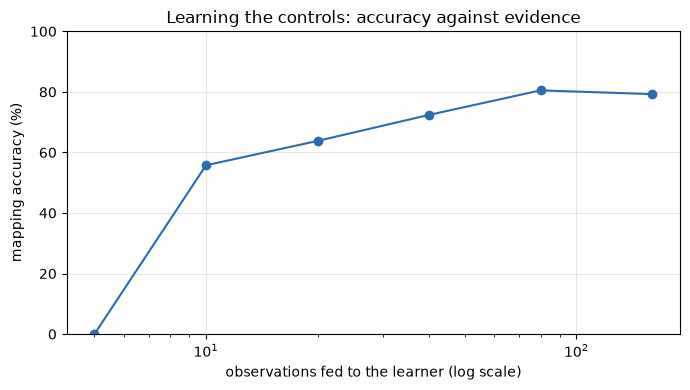

In [25]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot([r["observations"] for r in curve], [r["accuracy"] * 100 for r in curve],
        marker="o", color="#2b6cb0")
ax.set_xscale("log")
ax.set_xlabel("observations fed to the learner (log scale)")
ax.set_ylabel("mapping accuracy (%)")
ax.set_title("Learning the controls: accuracy against evidence")
ax.grid(alpha=0.3)
ax.set_ylim(0, 100)
plt.tight_layout()
plt.show()

Nothing is learnable below about ten observations; accuracy climbs to roughly
80% by eighty, then flattens. A separate measurement matters more in play: a
mapping *correct about two directions* costs a median of **12 observations**.
Those answer different questions, and conflating them — as we did — makes
starting look far more expensive than it is.

## 3. Is the learner's confidence honest?

It reports a confidence alongside each mapping. If that number means anything,
accuracy should rise with it.

    confidence  mappings  correct  accuracy
-------------------------------------------
       0.2-0.4         8        0       0%
       0.4-0.6       225       80      36%
       0.6-0.8       388      327      84%
       0.8-1.0       451      383      85%


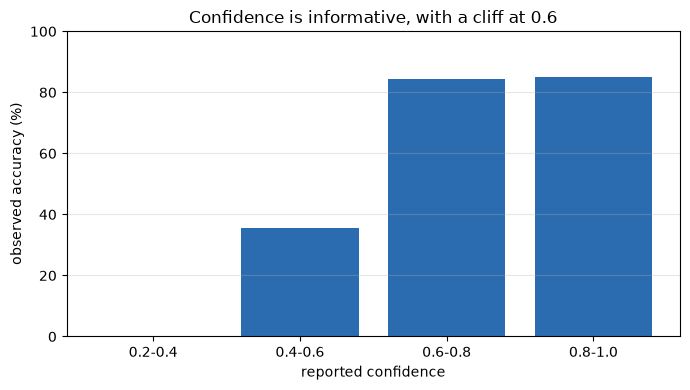

In [26]:
bands = measured["confidence_calibration"]
print(f"{'confidence':>14}{'mappings':>10}{'correct':>9}{'accuracy':>10}")
print("-" * 43)
for row in bands:
    label = f"{row['confidence_from']:.1f}-{row['confidence_to']:.1f}"
    print(f"{label:>14}{row['mappings']:>10}{row['correct']:>9}{row['accuracy']:>9.0%}")

fig, ax = plt.subplots(figsize=(7, 4))
labels = [f"{r['confidence_from']:.1f}-{r['confidence_to']:.1f}" for r in bands]
ax.bar(labels, [r["accuracy"] * 100 for r in bands], color="#2b6cb0")
ax.set_xlabel("reported confidence")
ax.set_ylabel("observed accuracy (%)")
ax.set_title("Confidence is informative, with a cliff at 0.6")
ax.set_ylim(0, 100)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

A sharp threshold at **0.6**: below it the mapping is 36% accurate, above it
84–85%. Waiting for higher confidence buys no further accuracy while costing
actions — and even the top band is wrong 15% of the time.

## 4. Five times the simulator convinced us

| # | Looked settled | Then failed | Mechanism |
|---|---|---|---|
| 1 | object matching, 88% in our mock | **0.4%** on 2,276 real transitions | an animating sprite does not match itself between frames |
| 2 | "the board changed" as a click signal | **worthless** — 91–100% of real clicks change the board | a signal present almost always separates nothing |
| 3 | our best walking policy, 3/3 levels | **0/3** once the board is noisy | the centre of mass is dragged sideways by animation |
| 4 | cell alignment, 3/3 on the *calibrated* mock | **55%** on real boards, against the centroid's 79% | alignment discards an observation whenever nothing lines up |
| 5 | the walker, 3/3 on our mock | pressed ACTION5 on **97–100%** of turns in all 8 real walking games offering it | our mock offered interaction only on the goal; the real engine fixes the action list for a whole game |

The fourth passed an arena calibrated from 500 real runs and still selected the
worse design: matching measured statistics is not sufficient, because the
statistics one chooses to match come from the same understanding that shaped the
method. The fifth was found by replaying recorded real boards through the agent
we were about to submit — the first of our three checks, again.

## 5. The fifth, reproduced

`static_actions=True` makes our mock behave like the real engine: the same
actions on every frame. The frozen walker against the one we submit:

In [27]:
from arcengine import GameAction

from arcagi3.router import walker as submitted_walker

SCRAMBLED = {GameAction.ACTION1: (0, 1), GameAction.ACTION2: (0, -1),
             GameAction.ACTION3: (1, 0), GameAction.ACTION4: (-1, 0)}
STATIC_ARENAS = {
    "quiet, list varies (our mock)": lambda: MockEnvironment(),
    "quiet, fixed list (engine)": lambda: MockEnvironment(static_actions=True),
    "noisy, fixed list": lambda: NoisyEnvironment(static_actions=True),
    "noisy, fixed, scrambled": lambda: NoisyEnvironment(moves=SCRAMBLED, static_actions=True),
}
WALKERS = {"frozen (dc949b4)": FrozenNavigator, "submitted": submitted_walker}

print(f"{'arena':<32}" + "".join(f"{name:>20}" for name in WALKERS))
print("-" * 72)
for arena, make in STATIC_ARENAS.items():
    print(f"{arena:<32}" + "".join(f"{outcome(w, make):>20}" for w in WALKERS.values()))

arena                               frozen (dc949b4)           submitted
------------------------------------------------------------------------
quiet, list varies (our mock)                WIN 3/3             WIN 3/3
quiet, fixed list (engine)                  lost 0/3             WIN 3/3
noisy, fixed list                           lost 0/3             WIN 3/3


noisy, fixed, scrambled                     lost 0/3             WIN 3/3


The frozen walker wins only the environment we wrote first. These are still
mocks: they show the mechanism was found and repaired, not that real levels are
now cleared — that is what the live run is for.

## 6. Which noise actually matters

Each property switched on separately, against our walking game, with the frozen
walker the ablation was measured on:

In [28]:
from arcagi3.noise import NoiseWrapper

PLAYER, GOAL = 4, 2
ABLATION = {
    "animate the controlled object only": dict(sprite_colour=PLAYER),
    "animate every small object": dict(),
    "animate only the goal": dict(sprite_colour=GOAL),
    "HUD alone, nothing animated": dict(animate=False),
    "controlled object, no HUD": dict(sprite_colour=PLAYER, hud=False),
}
for label, noise in ABLATION.items():
    r = run_episode(FrozenNavigator(), NoiseWrapper(MockEnvironment(), **noise), max_actions=400)
    print(f"{label:<40} clears {r.levels_completed} of {r.total_levels}")

animate the controlled object only       clears 0 of 3


animate every small object               clears 3 of 3
animate only the goal                    clears 3 of 3
HUD alone, nothing animated              clears 3 of 3
controlled object, no HUD                clears 0 of 3


More noise made the test **easier**. It is not noise that defeats learning, but
noise on the signal being learned from — a statement about learning agents
rather than about ARC.

## 7. Three checks

These would have caught all five of our failures, and need no ARC-specific
knowledge:

1. **Test against data you did not generate.** Recordings, traces, a live game.
2. **Measure the base rate of whatever signal you learn from.** A signal present
   95% of the time separates nothing, however reasonable it looks.
3. **Measure component accuracy and playing ability separately.** Ours diverged
   completely: 79% mapping accuracy, zero levels cleared.

The noise is packaged as a wrapper that takes any environment returning
`FrameData`, so the same check runs against another team's agent unchanged:

In [29]:
from arcagi3.click_mock import ClickEnvironment

frame = NoiseWrapper(ClickEnvironment()).reset()
print(f"wrapped a game it was not written for: board is "
      f"{len(frame.frame[-1])}x{len(frame.frame[-1][0])}")

wrapped a game it was not written for: board is 11x10


## Reproducing all of it

```bash
git clone https://github.com/Panus15/arc-prize-2026
cd arc-prize-2026/agi3 && ./setup.sh
.venv/bin/pytest                                          # the test suite
PYTHONPATH=. .venv/bin/python scripts/simulation_gap.py   # section 1
PYTHONPATH=. .venv/bin/python scripts/validate_control.py # sections 2 and 3
PYTHONPATH=. .venv/bin/python scripts/replay_traces.py    # failure 5, on real boards
PYTHONPATH=. .venv/bin/python scripts/static_arenas.py    # section 5, all arenas
```